#10/05/2025

Cell 0 — Acceleration & Environment Setup

In [ ]:
# ----------------------------
# 0.0 Threading & Env guards
# ----------------------------
# Put BLAS/OpenMP env vars *before* heavy imports (numpy/pandas/sklearn)
import os, sys, subprocess, platform, warnings, importlib, random
warnings.filterwarnings("ignore")

os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "4")

# Avoid PROJ network downloads at runtime (Geo stack stability)
os.environ.setdefault("PROJ_NETWORK", "OFF")

# ----------------------------
# 0.1 Install core dependencies
# ----------------------------
# - Earth Engine + geemap for GEE & mapping
# - geopandas/shapely/rtree/pyproj for vector I/O & spatial ops
# - scikit-learn (+ sklearnex) for CPU-accelerated ML via oneAPI MKL
# - torch (GPU if available, else CPU) for optional batch ops
# - folium/pillow/tqdm for UX & rendering
# Notes:
# * We keep versions unpinned but allow Colab-provided wheels for stability.
# * RasterIO is optional (heavy); we only probe if present.

# Core stack
!pip -q install -U \
  earthengine-api geemap folium \
  geopandas shapely rtree pyproj \
  scikit-learn scikit-learn-intelex \
  pillow tqdm

# PyTorch: try CUDA wheel if GPU is visible; otherwise install CPU wheel.
_has_gpu_env = bool(os.environ.get("COLAB_GPU") or os.environ.get("NVIDIA_VISIBLE_DEVICES"))
try:
    if _has_gpu_env:
        # Colab typically uses CUDA 12.x wheels. We install from the official index-url.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "torch", "--index-url", "https://download.pytorch.org/whl/cu121"])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])
except Exception as e:
    print("[WARN] CUDA wheel install failed; falling back to CPU torch:", e)
    subprocess.call([sys.executable, "-m", "pip", "install", "-q", "torch"])  # CPU fallback

# ----------------------------
# 0.2 Imports & version report
# ----------------------------
import numpy as np, pandas as pd

def _v(mod: str) -> str:
    try:
        m = importlib.import_module(mod)
        return getattr(m, "__version__", "n/a")
    except Exception:
        return "not-installed"

print("Python:", platform.python_version())
print("earthengine-api:", _v("ee"))
print("geemap:", _v("geemap"))
print("geopandas:", _v("geopandas"))
print("shapely:", _v("shapely"))
print("pyproj:", _v("pyproj"))
print("rtree:", _v("rtree"))
print("scikit-learn:", _v("sklearn"))
print("sklearnex:", _v("sklearnex"))
print("torch:", _v("torch"))
print("folium:", _v("folium"))
print("pillow:", _v("PIL"))
print("tqdm:", _v("tqdm"))

# Optional: confirm GDAL/GEOS/PROJ via providers (skip if not installed)
try:
    import rasterio
    from rasterio._base import gdal_version
    print("GDAL (via rasterio):", gdal_version())
except Exception:
    pass
try:
    from shapely import geos
    import pyproj
    print("GEOS:", getattr(geos, "geos_version_string", lambda: "n/a")())
    print("PROJ:", getattr(pyproj, "proj_version_str", getattr(pyproj, "__version__", "n/a")))
except Exception:
    pass

# -----------------------------------------
# 0.3 Enable CPU acceleration (Intel oneAPI)
# -----------------------------------------
# Patch scikit-learn to use MKL-optimized kernels transparently.
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("sklearnex patch applied (CPU acceleration via oneAPI/MKL).")
except Exception as e:
    print("[WARN] sklearnex patch skipped:", e)

# -----------------------------
# 0.4 GPU availability (PyTorch)
# -----------------------------
import torch
TORCH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if TORCH_DEVICE == "cuda":
    print(f"CUDA available → torch device: {TORCH_DEVICE} (GPU count={torch.cuda.device_count()})")
    try:
        print("GPU name:", torch.cuda.get_device_name(0))
    except Exception:
        pass
else:
    print("Using CPU for PyTorch-based steps (GPU not detected).")

# Make torch behavior deterministic for fair comparisons in clustering experiments
try:
    torch.manual_seed(42)
    if TORCH_DEVICE == "cuda":
        torch.cuda.manual_seed_all(42)
        import torch.backends.cudnn as cudnn
        cudnn.deterministic = True
        cudnn.benchmark = False
except Exception:
    pass

# -----------------------------------------
# 0.5 Colab widget manager (for geemap UI)
# -----------------------------------------
# Ensures ipywidgets rendering for geemap split maps, legends, draw controls, etc.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Widgets enabled for geemap.")
except Exception:
    print("[INFO] Colab widget manager not available; geemap will still try to render.")

# --------------------------------------
# 0.6 Earth Engine authentication helper
# --------------------------------------
import ee

def ee_init(project_id: "str | None" = None, verbose: bool = True) -> None:
    """Initialize Earth Engine and perform a quick health check.
    - If not authenticated, triggers interactive OAuth in Colab.
    - `project_id` is optional; pass your GEE project (e.g., 'roi-iran-project').
    - Prints a single-line status for clean notebooks.
    """
    def _healthy() -> bool:
        try:
            _ = ee.Number(1).getInfo()
            return True
        except Exception:
            return False
    try:
        ee.Initialize(project=project_id) if project_id else ee.Initialize()
        if not _healthy():
            raise RuntimeError("EE init healthcheck failed.")
        if verbose: print("EE initialized.")
    except Exception:
        if verbose: print("Running interactive authentication…")
        ee.Authenticate()
        ee.Initialize(project=project_id) if project_id else ee.Initialize()
        if _healthy():
            if verbose: print("EE initialized after auth.")
        else:
            raise RuntimeError("Earth Engine init failed after auth.")

# ---------------------------------
# 0.7 Reproducibility (global seed)
# ---------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Seed set:", SEED)

# --------------------------------------
# 0.8 Backend selector (CPU vs. GPU hint)
# --------------------------------------
from typing import Literal

def pick_backend(prefer: Literal["auto","cpu","gpu"] = "auto") -> str:
    """Return 'gpu' if available & preferred, else 'cpu'.
    Use this to choose between CPU/GPU variants of heavy routines later.
    """
    if prefer == "gpu" and torch.cuda.is_available():
        return "gpu"
    if prefer == "auto" and torch.cuda.is_available():
        return "gpu"
    return "cpu"

BACKEND = pick_backend("auto")
print("Selected backend:", BACKEND)

# --------------------------------------
# 0.9 Quick EE init call here
# --------------------------------------
# Set your default GEE project if you like. You can override per-session.
# Example: ee_init(project_id="roi-iran-project")
ee_init(project_id="roi-iran-project")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.2/463.2 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.4/631.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.7 MB/s eta 0:00:00
Python: 3.12.11
earthengine-api: 1.6.10
geemap: 0.36.4
geopandas: 1.1.1
shapely: 2.1.2
pyproj: 3.7.2
rtree: 1.4.1
scikit-learn: 1.7.2
sklearnex: 2199.9.9
torch: 2.8.0+cu126
folium: 0.20.0
pillow: 11.3.0
tqdm: 4.67.1
sklearnex patch applied (CPU acceleration via oneAPI/MKL).
Using CPU for PyTorch-based steps (GPU not detected).
Widgets enabled for geemap.
Seed set: 42
Selected backend: cpu
Running interactive authentication…


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


EE initialized after auth.


Cell 1 — Configuration & ROI / Thumbnail Utils

In [ ]:
from __future__ import annotations
import io, os, time, re
from typing import List, Tuple, Optional, Union

import numpy as np
from PIL import Image, UnidentifiedImageError
import requests
import ee  # Earth Engine (initialized in Cell 0 via ee_init())

# -----------------------------------------------------
# 1) High-level configuration (edit to your scenario)
# -----------------------------------------------------
# If you have a FeatureCollection asset with polygons, put it here.
# Examples:
#   "users/<username>/my_polygons"
#   "projects/<project-id>/assets/<collection-name>"
GEE_POLYGON_ASSET: Optional[str] = None   # e.g., "projects/roi-iran-project/assets/roi_polys/roi_union_xxx"

# Optional attribute filter on the polygon asset:
# - FILTER_PROP: property name to filter on (e.g., 'uses_fruit')
# - FILTER_VALUE: either a single value (int/str) OR a list of values
FILTER_PROP: Optional[str]  = None        # e.g., 'uses_fruit'
FILTER_VALUE: Optional[Union[int, str, List[Union[int, str]]]] = 4

# Fallback ROI (used when GEE_POLYGON_ASSET is None or load fails)
# → Edit these coordinates to your local study area (WGS84 lon/lat)
ROI_POLY = {
    "type": "Polygon",
    "coordinates": [[
        [48.8023652999652, 31.5241339777962],
        [48.6925020187152, 31.393225580127254],
        [48.7584199874652, 31.35805124835772],
        [48.88579272916442, 31.491643605037204],
        [48.8023652999652, 31.5241339777962]
    ]]
}

# Temporal window & cloudiness filter for Sentinel-2 (ISO YYYY-MM-DD)
DATE_FROM: str = "2025-02-20"
DATE_TO:   str = "2025-04-19"
MAX_CLOUD: int = 20  # [0..100]
print(f"Date window: {DATE_FROM} → {DATE_TO} | MAX_CLOUD: {MAX_CLOUD}%")

# ROI safety limits (keep Colab safe even if user draws huge polygons)
MAX_AREA_KM2: float   = 5000.0   # hard cap on area
MAX_VERTS: int        = 2000     # hard cap on vertex count after simplify
SIMPLIFY_M: float     = 5.0      # base simplify tolerance in meters (geodesic)
BUFFER_MAXERR_M: float = 1.0     # non-zero maxError for buffer(0) in EE

# -----------------------------------------------------
# 1.1 Light input validation (defensive & explainable)
# -----------------------------------------------------
_iso = re.compile(r"^\d{4}-\d{2}-\d{2}$")

def _validate_inputs() -> None:
    """Check dates/cloudiness/ROI format early; raise with clear messages."""
    if not (_iso.match(DATE_FROM) and _iso.match(DATE_TO)):
        raise ValueError("DATE_FROM/DATE_TO must be ISO 'YYYY-MM-DD'.")
    if DATE_FROM > DATE_TO:
        raise ValueError(f"DATE_FROM ({DATE_FROM}) must be ≤ DATE_TO ({DATE_TO}).")
    if not (0 <= int(MAX_CLOUD) <= 100):
        raise ValueError("MAX_CLOUD must be between 0 and 100.")
    if not isinstance(ROI_POLY, dict) or ROI_POLY.get("type") != "Polygon":
        raise ValueError("ROI_POLY must be a GeoJSON-like dict with type='Polygon'.")
    coords = ROI_POLY.get("coordinates")
    if not coords or not isinstance(coords, list) or not isinstance(coords[0], list) or len(coords[0]) < 4:
        raise ValueError("ROI_POLY.coordinates must be a ring with ≥4 vertices (lon,lat).")

_validate_inputs()

# -----------------------------------------------------
# 2) Lightweight client-side PNG / thumbnail helpers
# -----------------------------------------------------

def save_png(arr: np.ndarray, path: str, perc=(2, 98), gamma: float = 1.15) -> str:
    """
    Save an HxWx3 float array (0..1) to PNG with percentile stretch + gamma.
    * Quicklooks for reports. Does **not** change spatial resolution.
    """
    a = np.asarray(arr, dtype=np.float32)
    if a.ndim == 2:
        a = np.repeat(a[..., None], 3, axis=2)
    if a.ndim != 3 or a.shape[-1] != 3:
        raise ValueError("save_png expects HxWx3 or HxW array.")
    flat = a.reshape(-1, 3)
    lo = np.percentile(flat, perc[0], axis=0)
    hi = np.percentile(flat, perc[1], axis=0)
    a  = (a - lo) / (hi - lo + 1e-6)
    a  = np.clip(a, 0, 1)
    if gamma and gamma > 0:
        a = a ** (1.0 / gamma)
    Image.fromarray((a * 255).astype(np.uint8)).save(path)
    print("saved:", path)
    return path

def _to_region_geometry(region_like):
    """
    Coerce a region to ee.Geometry.Polygon.
    Accepts ee.Geometry or a ring-like list [[minx,miny],[minx,maxy],[maxx,maxy],[maxx,miny],[minx,miny]].
    """
    if isinstance(region_like, ee.Geometry):
        return region_like
    return ee.Geometry.Polygon([region_like])

def download_thumb(ee_image_or_ic, params: dict, out_png: str,
                   retries: int = 3, timeout: int = 120, backoff: float = 1.5) -> str:
    """
    Download a server-side thumbnail (EE getThumbURL) with retries and content check.
    - Accepts ee.Image or ee.ImageCollection (mosaics collections).
    - `params` must include 'region' (ee.Geometry or ring list) and either 'scale' or 'dimensions'.
    - Rebuilds signed URL at every retry (EE URLs are short-lived).
    """
    # Normalize to ee.Image
    if isinstance(ee_image_or_ic, ee.imagecollection.ImageCollection):
        ee_img = ee_image_or_ic.mosaic()
    elif isinstance(ee_image_or_ic, ee.image.Image):
        ee_img = ee_image_or_ic
    else:
        raise TypeError("ee_image_or_ic must be ee.Image or ee.ImageCollection")

    if "region" not in params:
        raise ValueError("params must include a 'region' (ee.Geometry or ring list)")

    region_geom = _to_region_geometry(params["region"])
    params_eff = dict(params)
    params_eff["region"] = region_geom
    params_eff.setdefault("format", "png")

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            url = ee_img.getThumbURL(params_eff)
            resp = requests.get(url, timeout=timeout, headers={"User-Agent": "gee-colab/1.0"})
            resp.raise_for_status()
            # Light content sanity: must be a PNG
            if resp.headers.get("Content-Type", "").lower().find("png") == -1:
                raise OSError(f"Unexpected content-type: {resp.headers.get('Content-Type')}")
            Image.open(io.BytesIO(resp.content)).save(out_png, optimize=True)
            print(f"saved: {out_png} (attempt {attempt}/{retries})")
            return out_png
        except (requests.RequestException, UnidentifiedImageError, OSError) as e:
            last_err = e
            print(f"[download_thumb] attempt {attempt}/{retries} failed: {e}")
            if attempt < retries:
                time.sleep(backoff ** attempt)
    raise RuntimeError(f"Failed to download thumbnail after {retries} attempts: {last_err}")

# -----------------------------------------------------
# 3) Geometry safety utilities (area/vertex limits)
# -----------------------------------------------------

def _bounds_ring(geom: ee.Geometry) -> List[List[float]]:
    """
    Return a simple rectangular ring (bounds) for a geometry.
    Shape: [[minx,miny],[minx,maxy],[maxx,maxy],[maxx,miny],[minx,miny]].
    Uses a tiny getInfo() (5 vertices) → safe in Colab.
    """
    rect = ee.Geometry(geom).bounds().coordinates().get(0)
    return ee.List(rect).getInfo()

def _geom_area_km2(geom: ee.Geometry) -> float:
    """Area in km² (spherical); tiny getInfo payload."""
    return float(ee.Number(ee.Geometry(geom).area(1)).divide(1e6).getInfo())

def _geom_vertex_count(geom: ee.Geometry) -> int:
    """Approximate vertex count from coordinates array (tiny getInfo)."""
    coords = ee.Geometry(geom).coordinates()
    try:
        return int(ee.Number(coords.flatten().length()).getInfo())
    except Exception:
        return int(ee.Number(coords.length()).getInfo())

def sanitize_geometry(geom: ee.Geometry,
                      simplify_m: float = SIMPLIFY_M,
                      dissolve: bool = True,
                      buffer_maxerr_m: float = BUFFER_MAXERR_M) -> ee.Geometry:
    """
    Dissolve & simplify geometry on the EE server side to keep it light.
    - dissolve via buffer(0, maxError) to fix topology and merge parts.
    - simplify tolerance in meters (geodesic).
    """
    g = ee.Geometry(geom)
    if dissolve:
        g = g.buffer(0, buffer_maxerr_m)
    if simplify_m and simplify_m > 0:
        g = g.simplify(simplify_m)
    return g

def validate_geometry_limits(geom: ee.Geometry,
                             max_area_km2: float = MAX_AREA_KM2,
                             max_vertices: int = MAX_VERTS) -> Tuple[bool, str]:
    """
    Check geometry safety: area and vertex count after sanitize. Returns (ok, message).
    """
    g = sanitize_geometry(geom)
    A = _geom_area_km2(g)
    V = _geom_vertex_count(g)
    if A > max_area_km2:
        return False, f"Area too large: {A:.1f} km² (max {max_area_km2}). Draw/select a smaller ROI."
    if V > max_vertices:
        return False, f"Too many vertices: {V} (max {max_vertices}). Increase SIMPLIFY_M or draw simpler geometry."
    return True, f"OK: area={A:.2f} km², vertices≈{V}"

# -----------------------------------------------------
# 4) ROI / geometry loader (call AFTER ee_init in Cell 0)
# -----------------------------------------------------

def _apply_optional_filter(fc: ee.FeatureCollection,
                           prop: Optional[str],
                           value: Optional[Union[int, str, List[Union[int, str]]]]
                           ) -> ee.FeatureCollection:
    """Apply attribute filter if provided; supports scalar or list values."""
    if not prop or value is None:
        return fc
    if isinstance(value, list):
        return fc.filter(ee.Filter.inList(prop, value))
    return fc.filter(ee.Filter.eq(prop, value))

def load_mask_geometry() -> Tuple[ee.Geometry, List[float], List[List[float]], List[float], str]:
    """
    Build the processing geometry from a GEE asset if provided, else fallback ROI.
    Also returns helpers for thumbnails and map centering.
    Returns:
        geom_mask         : ee.Geometry used across the pipeline
        BBOX              : [minx, miny, maxx, maxy] (client-side list)
        REGION_FOR_THUMBS : rectangular ring (client-side list) for thumbnails
        CENTER_LATLON     : [lat, lon] for map centering
        SOURCE_LABEL      : string describing where geometry came from
    """
    geom_mask = None
    source = "Fallback ROI_POLY"

    # Try to load polygons from a GEE asset (and optionally filter)
    if GEE_POLYGON_ASSET:
        try:
            fc = ee.FeatureCollection(GEE_POLYGON_ASSET)
            # Light server-side poke to fail early if asset is invalid or permission missing
            _ = fc.size().getInfo()
            fc = _apply_optional_filter(fc, FILTER_PROP, FILTER_VALUE)

            # In case the filter removed all features
            if int(fc.size().getInfo() or 0) == 0:
                raise RuntimeError("Asset loaded but filter removed all features.")

            geom_mask = fc.geometry()
            geom_mask = sanitize_geometry(geom_mask, simplify_m=SIMPLIFY_M, dissolve=True)

            ok, msg = validate_geometry_limits(geom_mask)
            print(f"[Asset geometry] {msg}")
            if not ok:
                raise RuntimeError(msg)

            source = f"GEE asset ({GEE_POLYGON_ASSET})"
        except Exception as e:
            print(f"[WARN] Failed to load/validate asset '{GEE_POLYGON_ASSET}': {e}")
            print("[INFO] Falling back to ROI_POLY.")

    # Fallback to manual ROI polygon or its bounding rectangle
    if geom_mask is None:
        try:
            geom_mask = ee.Geometry.Polygon(ROI_POLY["coordinates"])
        except Exception:
            # Coerce to bbox if needed
            coords = ROI_POLY["coordinates"][0]
            xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
            minx, maxx = min(xs), max(xs)
            miny, maxy = min(ys), max(ys)
            geom_mask = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

        geom_mask = sanitize_geometry(geom_mask, simplify_m=SIMPLIFY_M, dissolve=True)
        ok, msg = validate_geometry_limits(geom_mask)
        print(f"[Fallback geometry] {msg}")
        if not ok:
            raise RuntimeError(msg)

    # Derive client-side helpers (tiny payload)
    ring = _bounds_ring(geom_mask)
    minx, miny = ring[0][0], ring[0][1]
    maxx, maxy = ring[2][0], ring[2][1]
    BBOX = [minx, miny, maxx, maxy]
    REGION_FOR_THUMBS = ring
    CENTER_LATLON = [ (miny + maxy) / 2.0, (minx + maxx) / 2.0 ]

    print(f"Mask geometry loaded. (source: {source})")
    print("BBOX:", BBOX)
    return geom_mask, BBOX, REGION_FOR_THUMBS, CENTER_LATLON, source


Date window: 2025-02-20 → 2025-04-19 | MAX_CLOUD: 20%


Cell 2 — ROI Drawer + Save-to-Asset + Status Monitor

In [3]:
from __future__ import annotations
import os, time, threading, traceback
from datetime import datetime, timezone
from typing import Optional, Tuple, List

import ipywidgets as widgets
from IPython.display import display, clear_output
import geemap, ee, geopandas as gpd
from shapely.geometry import mapping
from shapely.ops import unary_union

# ---------------------- USER CONFIG ----------------------
PROJECT_ID        = "roi-iran-project"    # your EE project id
ASSET_FOLDER      = "roi_polys"           # projects/<PROJECT_ID>/assets/<ASSET_FOLDER>
ASSET_PREFIX      = "roi_"                # file prefix for quick filtering
MAX_AREA_KM2      = 5000.0                # area guardrail (prevents RAM blow-ups)
MAX_VERTS         = 2000                  # vertex guardrail after simplify
SIMPLIFY_M        = 5.0                   # simplify tolerance (meters, geodesic)
BUFFER_MAXERR_M   = 1.0                   # non-zero maxError for buffer(0)
START_LAT, START_LON, START_ZOOM = 35.7, 51.4, 7
BASEMAP           = "Esri.WorldImagery"

# ---------------------- EE INIT (idempotent) ----------------------
def _ee_quick_init(project_id: Optional[str] = None):
    """Ensure Earth Engine is initialized (uses ee_init from Cell 0 if available)."""
    try:
        _ = ee.Number(1).getInfo()
    except Exception:
        try:
            ee_init(project_id)  # defined in Cell 0
        except Exception:
            ee.Authenticate()
            ee.Initialize(project=project_id)

_ee_quick_init(PROJECT_ID)

# ---------------------- Globals exported to other cells ----------------------
GEE_POLYGON_ASSET: Optional[str] = None
BATCH_ROIS: List[str] = []
LATEST_ROI_ASSET: Optional[str] = None

# ---------------------- UI: Header & Buttons ----------------------
lbl_title = widgets.HTML("<h3 style='margin:4px 0'>ROI Drawer → Export to GEE Asset</h3>")
lbl_help  = widgets.HTML(
    f"<p style='margin:0'>Draw polygon(s) with the red tool. Then click <b>Save to Asset</b>.<br>"
    f"Limits: area ≤ <b>{MAX_AREA_KM2:.0f} km²</b>, vertices ≤ <b>{MAX_VERTS}</b>. "
    f"Geometry will be <i>dissolved</i> and <i>simplified</i> ({SIMPLIFY_M:.1f} m).</p>"
)

# Drawing / preview controls
btn_start   = widgets.Button(description="Start Drawing", layout=widgets.Layout(width='140px'))
btn_reset   = widgets.Button(description="Reset", layout=widgets.Layout(width='90px'))
btn_capture = widgets.Button(description="Capture Now", layout=widgets.Layout(width='130px'))
btn_preview = widgets.Button(description="Refresh Preview", layout=widgets.Layout(width='150px'))
btn_save    = widgets.Button(description="Save to Asset", button_style="primary", layout=widgets.Layout(width='150px'))

# Task monitor controls
btn_check   = widgets.Button(description="Check Status", layout=widgets.Layout(width='130px'))
btn_watch   = widgets.ToggleButton(value=False, description="Auto-Watch", icon="eye", layout=widgets.Layout(width='120px'))
btn_cancel  = widgets.Button(description="Cancel Task", layout=widgets.Layout(width='120px'))

# Asset picker (single + multi-select for batch)
ddl_assets   = widgets.Dropdown(options=[], description="Assets:", layout=widgets.Layout(width='520px'))
msel_assets  = widgets.SelectMultiple(options=[], description="Batch:", layout=widgets.Layout(width='520px', height='140px'))
btn_reload   = widgets.Button(description="Reload List", layout=widgets.Layout(width='110px'))
btn_use      = widgets.Button(description="Use Selected ROI", layout=widgets.Layout(width='160px'))
btn_build_bt = widgets.Button(description="Build Batch List", layout=widgets.Layout(width='150px'))

# Status & task outputs
out_status  = widgets.Output(layout={"border": "1px solid #ddd", "max_height": "210px", "overflow_y": "auto"})
out_tasks   = widgets.Output(layout={"border": "1px solid #ddd", "max_height": "180px", "overflow_y": "auto"})

display(
    widgets.VBox([
        lbl_title, lbl_help,
        widgets.HBox([btn_start, btn_reset, btn_capture, btn_preview, btn_save]),
        widgets.HBox([btn_check, btn_watch, btn_cancel, btn_reload, btn_use, btn_build_bt]),
        ddl_assets,
        widgets.HTML("<b>Batch selection (hold Ctrl/Cmd for multi-select)</b>"),
        msel_assets,
        widgets.HTML("<b>Status / Logs</b>"),
        out_status,
        widgets.HTML("<b>Task Monitor</b>"),
        out_tasks
    ])
)

# ---------------------- Map & Draw Control ----------------------
# Set map height for nicer UX in Colab.
m = geemap.Map(center=[START_LAT, START_LON], zoom=START_ZOOM, height="520px")
try:
    m.add_basemap(BASEMAP)
except Exception:
    # Fallback in case basemap is unavailable.
    m.add_basemap("HYBRID")

# Configure drawing: allow only polygons; style in red
draw_ctrl = m.draw_control
draw_ctrl.polyline = {}
draw_ctrl.rectangle = {}
draw_ctrl.circle = {}
draw_ctrl.circlemarker = {}
draw_ctrl.marker = {}
draw_ctrl.polygon = {"shapeOptions": {"color": "#FF0000", "weight": 3, "fillOpacity": 0.15}}

# Hint on the map (optional; silently ignore if geemap lacks add_text)
try:
    m.add_text("Use the red polygon tool. Double-click to finish.", font_size="12pt", position="topcenter")
except Exception:
    pass

display(m)

# ---------------------- Internal State ----------------------
_drawn_fc_geojson = {"type": "FeatureCollection", "features": []}  # in-memory drawings
_last_fc: Optional[ee.FeatureCollection] = None                     # last exported FC (for debug)
_last_task_id: Optional[str] = None                                 # last export task id

# ---------------------- Helpers: geometry & layers ----------------------
def _remove_layers(names: List[str]):
    """Remove named layers from geemap Map (keeps base layer)."""
    for lyr in list(m.layers)[1:]:
        if getattr(lyr, "name", "") in names:
            try:
                m.remove(lyr)
            except Exception:
                pass

def _sync_from_drawctrl():
    """Rebuild our GeoJSON FeatureCollection from draw_control.data."""
    feats = []
    for item in (draw_ctrl.data or []):
        geom = item.get("geometry", {})
        if geom and geom.get("type") in ("Polygon", "MultiPolygon"):
            feats.append({"type": "Feature", "geometry": geom, "properties": {}})
    _drawn_fc_geojson["features"] = feats

def _gdf_union_wgs84(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Fix, dissolve, and ensure EPSG:4326."""
    gdf = gdf[gdf.geometry.notnull()].copy()
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    else:
        gdf = gdf.to_crs(4326)
    gdf["geometry"] = gdf["geometry"].buffer(0)  # fix topology
    geom = unary_union(gdf.geometry)
    return gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")

def _to_ee_geom_from_geojson_fc(geojson_fc: dict) -> ee.Geometry:
    """Convert our FC GeoJSON into an ee.Geometry with simplify/buffer."""
    if not geojson_fc or not geojson_fc.get("features"):
        raise ValueError("No polygon features to convert.")
    gdf = gpd.GeoDataFrame.from_features(geojson_fc["features"], crs="EPSG:4326")
    gdf = _gdf_union_wgs84(gdf)
    geom = ee.Geometry(mapping(gdf.iloc[0].geometry)).buffer(0, BUFFER_MAXERR_M)
    if SIMPLIFY_M and SIMPLIFY_M > 0:
        geom = geom.simplify(SIMPLIFY_M)  # geodesic simplify
    return geom

def _area_km2(geom: ee.Geometry) -> float:
    return float(ee.Number(ee.Geometry(geom).area(1)).divide(1e6).getInfo())

def _vertex_count(geom: ee.Geometry) -> int:
    coords = ee.Geometry(geom).coordinates()
    try:
        return int(ee.Number(coords.flatten().length()).getInfo())
    except Exception:
        return int(ee.Number(coords.length()).getInfo())

def _validate_limits(geom: ee.Geometry) -> Tuple[bool, str]:
    """Check area/vertex caps and compose a human-friendly message."""
    try:
        A = _area_km2(geom)
        V = _vertex_count(geom)
    except Exception as e:
        return False, f"[EE] geometry analysis failed: {e}"
    if A > MAX_AREA_KM2:
        return False, f"Area too large: {A:.1f} km² (max {MAX_AREA_KM2})."
    if V > MAX_VERTS:
        return False, f"Too many vertices: {V} (max {MAX_VERTS}). Increase SIMPLIFY_M or draw simpler geometry."
    return True, f"OK — area={A:.2f} km², vertices≈{V}"

def _fit_to_geom(geom: ee.Geometry):
    """Zoom the map to the geometry bounds (better UX for preview)."""
    try:
        ring = ee.Geometry(geom).bounds().coordinates().get(0)
        ring = ee.List(ring).getInfo()
        minx, miny = ring[0][0], ring[0][1]
        maxx, maxy = ring[2][0], ring[2][1]
        m.fit_bounds([[miny, minx], [maxy, maxx]])
    except Exception:
        pass

def _preview_outline(geom: ee.Geometry, name="ROI outline", color="#00FFFF", weight=4, opacity=0.9):
    """Add an EE raster outline + semi-transparent fill for clear preview."""
    try:
        outline = ee.Image().paint(ee.FeatureCollection(ee.Feature(geom)), 1, weight)\
                            .visualize(palette=[color], opacity=opacity)
        fill = ee.Image().paint(ee.FeatureCollection(ee.Feature(geom)), 1)\
                         .visualize(palette=["#00FFFF"], opacity=0.08)
        _remove_layers([name, "ROI fill"])
        m.add_layer(fill, {}, "ROI fill")
        m.add_layer(outline, {}, name)
        _fit_to_geom(geom)
    except Exception as e:
        with out_status:
            print("[Preview] skipped:", e)

# ---------------------- Helpers: assets & export ----------------------
def _ensure_asset_folder(asset_folder_path: str):
    """Create folder if it does not exist: projects/<PROJECT_ID>/assets/<ASSET_FOLDER>"""
    try:
        ee.data.createAsset({"type": "FOLDER"}, asset_folder_path)
    except Exception:
        pass  # already exists / or insufficient permission

def _build_asset_id() -> str:
    ts = int(time.time() * 1000)
    return f"projects/{PROJECT_ID}/assets/{ASSET_FOLDER}/{ASSET_PREFIX}{ts}"

def _export_fc_to_asset(fc: ee.FeatureCollection, asset_id: str) -> str:
    """Start export → return task id."""
    task = ee.batch.Export.table.toAsset(
        collection=fc,
        description=f"export_{os.path.basename(asset_id)}",
        assetId=asset_id
    )
    task.start()
    return task.id

def _list_assets_in_folder(project_id: str, folder: str) -> List[str]:
    """List FeatureCollection assets under projects/<project>/assets/<folder> (optionally filter by prefix)."""
    root = f"projects/{project_id}/assets/{folder}"
    try:
        items = ee.data.listAssets({"parent": root}).get("assets", [])
    except Exception:
        items = []
    # keep only TABLE assets (FeatureCollection) and (optionally) with prefix
    out = []
    for a in items:
        if a.get("type") == "TABLE":
            name = a.get("name", "")
            base = os.path.basename(name)
            if ASSET_PREFIX and not base.startswith(ASSET_PREFIX):
                continue
            out.append(name)
    return out

# ---------------------- Draw Callback (robust signature) ----------------------
def _on_draw_handler(*args, **kwargs):
    """Handle draw events (created/edited/deleted) from geemap/ipyleaflet."""
    action = kwargs.get("action") or (args[1] if len(args) > 1 else None)
    geo_json = kwargs.get("geo_json") or (args[2] if len(args) > 2 else None)
    with out_status:
        if action == "created" and geo_json and geo_json.get("geometry", {}).get("type") in ("Polygon", "MultiPolygon"):
            _drawn_fc_geojson["features"].append({"type": "Feature", "geometry": geo_json["geometry"], "properties": {}})
            print(f"Polygon added. Parts now: {len(_drawn_fc_geojson['features'])}")
        elif action == "edited":
            _sync_from_drawctrl()
            print("Polygons edited.")
        elif action == "deleted":
            _drawn_fc_geojson["features"].clear()
            print("All drawings deleted.")

draw_ctrl.on_draw(_on_draw_handler)

# ---------------------- Button Handlers: drawing & export ----------------------
@out_status.capture(clear_output=True)
def _on_start(_):
    draw_ctrl.data = []
    _drawn_fc_geojson["features"].clear()
    _remove_layers(["ROI outline", "ROI fill"])
    print("Drawing ON → Use the red polygon tool. Double-click to finish. You can add multiple parts; they will be dissolved on save.")

@out_status.capture(clear_output=True)
def _on_reset(_):
    draw_ctrl.data = []
    _drawn_fc_geojson["features"].clear()
    _remove_layers(["ROI outline", "ROI fill"])
    print("Cleared drawings and overlays.")

@out_status.capture(clear_output=True)
def _on_capture(_):
    _sync_from_drawctrl()
    print(f"Captured shapes from toolbar: {len(_drawn_fc_geojson['features'])} polygon(s).")

@out_status.capture(clear_output=True)
def _on_preview(_):
    _sync_from_drawctrl()
    if not _drawn_fc_geojson["features"]:
        print("No geometry drawn. Click <Start Drawing> and create a polygon.")
        return
    try:
        ee_geom = _to_ee_geom_from_geojson_fc(_drawn_fc_geojson)
        ok, msg = _validate_limits(ee_geom)
        _preview_outline(ee_geom)
        print(msg)
    except Exception:
        print("Failed to build/preview geometry:")
        traceback.print_exc(limit=1)

@out_status.capture(clear_output=True)
def _on_save(_):
    """Export the unioned/simplified geometry as a single-feature FeatureCollection asset."""
    global _last_fc, _last_task_id, LATEST_ROI_ASSET, GEE_POLYGON_ASSET
    _sync_from_drawctrl()
    if not _drawn_fc_geojson["features"]:
        print("No geometry drawn. Click <Start Drawing> and create a polygon.")
        return
    try:
        ee_geom = _to_ee_geom_from_geojson_fc(_drawn_fc_geojson)
    except Exception as e:
        print("Geometry conversion failed:", e)
        return

    ok, msg = _validate_limits(ee_geom)
    _preview_outline(ee_geom)
    print(msg)
    if not ok:
        return

    created_at = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    area_km2 = float(ee.Number(ee_geom.area(1)).divide(1e6).getInfo())
    feat = ee.Feature(ee_geom, {"created_at": created_at, "area_km2": area_km2})
    fc = ee.FeatureCollection([feat])

    parent = f"projects/{PROJECT_ID}/assets/{ASSET_FOLDER}"
    _ensure_asset_folder(parent)
    asset_id = _build_asset_id()
    try:
        task_id = _export_fc_to_asset(fc, asset_id)
        _last_fc, _last_task_id = fc, task_id
        LATEST_ROI_ASSET = asset_id
        GEE_POLYGON_ASSET = asset_id  # make it immediately available to downstream cells
        print("Export started.")
        print("• Asset:", asset_id)
        print("• Task ID:", task_id)
        print("Use the buttons in the Task Monitor to check status here in Colab.")
        _reload_assets_list()  # refresh dropdowns
    except Exception as e:
        print("Export failed:", e)

# ---------------------- Task Monitor ----------------------
def _status_text(s: dict) -> str:
    """Render a compact single-line status for a task dict."""
    state = s.get("state")
    ttype = s.get("task_type", "")
    desc  = s.get("description", "")
    msg   = s.get("error_message", "") or ""
    return f"[{state}] {ttype} :: {desc}  {('— ' + msg) if msg else ''}"

def _check_last_task():
    """Check status of the last started export task and print it."""
    with out_tasks:
        clear_output(wait=True)
        if not _last_task_id:
            print("Task (empty) → state: UNKNOWN")
            return
        try:
            st = ee.data.getTaskStatus(_last_task_id)[0]
            print(_status_text(st))
            # Auto-stop watching when terminal state is reached.
            if st["state"] in ("COMPLETED", "FAILED", "CANCELLED"):
                if btn_watch.value:
                    btn_watch.value = False
        except Exception as e:
            print("Status check failed:", e)

_watch_thread = None
_watch_stop   = False

def _watch_loop():
    """Background polling (every 5 s) until stopped or task finishes."""
    global _watch_stop
    while not _watch_stop:
        _check_last_task()
        time.sleep(5)

@out_tasks.capture(clear_output=False)
def _on_check(_):
    _check_last_task()

@out_tasks.capture(clear_output=False)
def _on_watch(toggle):
    """Start/stop background polling of the last task."""
    global _watch_thread, _watch_stop
    if toggle.new:  # turned on
        if not _last_task_id:
            print("No task to watch. Start an export first.")
            btn_watch.value = False
            return
        print("Watching last task…")
        _watch_stop = False
        _watch_thread = threading.Thread(target=_watch_loop, daemon=True)
        _watch_thread.start()
    else:
        _watch_stop = True
        print("Watch stopped.")

@out_tasks.capture(clear_output=False)
def _on_cancel(_):
    if not _last_task_id:
        print("No task to cancel.")
        return
    try:
        ee.data.cancelTask(_last_task_id)
        print("Task cancel requested:", _last_task_id)
        # Stop watching if user cancels.
        if btn_watch.value:
            btn_watch.value = False
    except Exception as e:
        print("Cancel failed:", e)

# ---------------------- Asset Picker (single & batch) ----------------------
def _reload_assets_list():
    opts = _list_assets_in_folder(PROJECT_ID, ASSET_FOLDER)
    if not opts:
        ddl_assets.options = []
        msel_assets.options = []
    else:
        pairs = [(os.path.basename(o), o) for o in sorted(opts)]
        ddl_assets.options = pairs
        msel_assets.options = pairs

@out_status.capture(clear_output=False)
def _on_reload(_):
    _reload_assets_list()
    print("Asset list refreshed.")

@out_status.capture(clear_output=False)
def _on_use(_):
    """Publish the selected asset path for downstream cells."""
    global GEE_POLYGON_ASSET
    val = ddl_assets.value
    if not val:
        print("Select an asset first.")
        return
    GEE_POLYGON_ASSET = val  # <- used by next cells
    print("GEE_POLYGON_ASSET set to:", val)

@out_status.capture(clear_output=False)
def _on_build_batch(_):
    """Build a batch list from the multiple selection widget."""
    global BATCH_ROIS
    sel = list(msel_assets.value or [])
    if not sel:
        print("Select one or more assets in the Batch box.")
        return
    BATCH_ROIS = sel[:]  # copy
    print("BATCH_ROIS prepared with", len(BATCH_ROIS), "asset(s).")

# ---------------------- Wire up buttons ----------------------
btn_start.on_click(_on_start)
btn_reset.on_click(_on_reset)
btn_capture.on_click(_on_capture)
btn_preview.on_click(_on_preview)
btn_save.on_click(_on_save)

btn_check.on_click(_on_check)
btn_watch.observe(_on_watch, names="value")
btn_cancel.on_click(_on_cancel)

btn_reload.on_click(_on_reload)
btn_use.on_click(_on_use)
btn_build_bt.on_click(_on_build_batch)

# Initial load of asset lists + initial hints
_reload_assets_list()
with out_status:
    print("ROI drawer ready. Draw → Preview → Save. Then monitor export below.")
    print("• Use 'Reload List' to refresh assets, 'Use Selected ROI' to set GEE_POLYGON_ASSET.")
    print("• Select multiple assets in 'Batch' and click 'Build Batch List' to set BATCH_ROIS.")

Map(center=[35.7, 51.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

Cell 3 — Geometry I/O (from GEE Asset OR Local File) + Safety & Summary

In [4]:
from __future__ import annotations
import os
from pathlib import Path
from typing import Optional, List, Tuple

import ee, geemap
import geopandas as gpd
import pandas as pd
from shapely.geometry import mapping

# ---------- Safety / simplification knobs (keep consistent with Cell 2) ----------
MAX_AREA_KM2    = 5000.0   # hard cap for area after dissolve/simplify
MAX_VERTS       = 2000     # hard cap for vertex count after simplify
SIMPLIFY_M      = 5.0      # geodesic simplify tolerance (meters)
BUFFER_MAXERR_M = 1.0      # non-zero maxError for buffer(0)

# ---------- Optional local file fallback (only used if no GEE asset is selected) ----------
try:
    POLY_PATH
except NameError:
    POLY_PATH = None  # set to a local path if needed

# ---------- Helpers ----------
def _sanitize_geom(g: ee.Geometry,
                   simplify_m: float = SIMPLIFY_M,
                   buffer_maxerr_m: float = BUFFER_MAXERR_M) -> ee.Geometry:
    """Fix topology (buffer(0)) and simplify the geometry on the server side."""
    g2 = ee.Geometry(g).buffer(0, buffer_maxerr_m)
    if simplify_m and simplify_m > 0:
        g2 = g2.simplify(simplify_m)
    return g2

def _is_empty_geom(g: ee.Geometry) -> bool:
    """Return True if geometry is empty or invalid server-side."""
    try:
        # area(1) is safe and tiny; empty geometries return 0
        a = ee.Number(ee.Geometry(g).area(1)).getInfo()
        return (a is None) or (float(a) == 0.0)
    except Exception:
        return True

def _area_km2(g: ee.Geometry) -> float:
    """Area in km² (spherical) — tiny getInfo()."""
    return float(ee.Number(ee.Geometry(g).area(1)).divide(1e6).getInfo())

def _vertex_count(g: ee.Geometry) -> int:
    """Approximate vertex count from coordinates — tiny getInfo()."""
    coords = ee.Geometry(g).coordinates()
    try:
        return int(ee.Number(coords.flatten().length()).getInfo())
    except Exception:
        return int(ee.Number(coords.length()).getInfo())

def _validate_limits(g: ee.Geometry,
                     max_area_km2: float = MAX_AREA_KM2,
                     max_vertices: int = MAX_VERTS) -> Tuple[bool, str]:
    """Check area/vertex caps and compose a user-friendly message."""
    if _is_empty_geom(g):
        return False, "Geometry is empty after dissolve/simplify. Check your ROI polygons."
    A = _area_km2(g)
    V = _vertex_count(g)
    if A > max_area_km2:
        return False, f"Area too large: {A:.1f} km² (max {max_area_km2}). Draw/select a smaller ROI."
    if V > max_vertices:
        return False, f"Too many vertices: {V} (max {max_vertices}). Increase SIMPLIFY_M or draw simpler geometry."
    return True, f"OK — area={A:.2f} km², vertices≈{V}"

def _bounds_ring(g: ee.Geometry) -> List[List[float]]:
    """Rectangular ring [[minx,miny],[minx,maxy],[maxx,maxy],[maxx,miny],[minx,miny]]."""
    rect = ee.Geometry(g).bounds().coordinates().get(0)
    return ee.List(rect).getInfo()  # tiny (5 vertices)

def _gdf_from_file(path: str) -> gpd.GeoDataFrame:
    """Read polygons from GeoJSON/GPKG or zipped Shapefile and ensure WGS84 + valid geometries."""
    p = Path(path)
    assert p.exists(), f"Polygon file not found: {p}"
    if p.suffix.lower() == ".zip":
        gdf = gpd.read_file(f"zip://{str(p)}")
    else:
        gdf = gpd.read_file(str(p))
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf["geometry"] = gdf["geometry"].buffer(0)  # fix topology
    if "poly_id" not in gdf.columns:
        gdf = gdf.reset_index(names="poly_id")
    return gdf

def _fc_from_gdf(gdf: gpd.GeoDataFrame) -> ee.FeatureCollection:
    """Convert GeoDataFrame to EE FeatureCollection, keeping non-geometry attributes."""
    keep = [c for c in gdf.columns if c != "geometry"]
    feats = []
    for _, r in gdf.iterrows():
        geom = ee.Geometry(mapping(r.geometry))
        props = {k: (None if pd.isna(r[k]) else r[k]) for k in keep}
        feats.append(ee.Feature(geom, props))
    return ee.FeatureCollection(feats)

def _fc_from_asset(asset_id: str) -> ee.FeatureCollection:
    """Load FeatureCollection from a GEE asset path with a small permission check."""
    fc = ee.FeatureCollection(asset_id)
    _ = fc.size().getInfo()  # fail early if permissions are missing
    return fc

def _union_fc(fc: ee.FeatureCollection) -> ee.Geometry:
    """Dissolve FeatureCollection to a single ee.Geometry, then sanitize."""
    g = fc.geometry()
    return _sanitize_geom(g)

def _preview_on_map(aoi: ee.Geometry, title: str = "AOI"):
    """Quick geemap preview: outline + semi-transparent fill + auto-zoom."""
    try:
        m = geemap.Map(center=[35.7, 51.4], zoom=5, height="480px")
        try:
            m.add_basemap("Esri.WorldImagery")
        except Exception:
            m.add_basemap("HYBRID")
        outline = ee.Image().paint(ee.FeatureCollection(ee.Feature(aoi)), 1, 3)\
                            .visualize(palette=["#00FFFF"], opacity=0.9)
        fill    = ee.Image().paint(ee.FeatureCollection(ee.Feature(aoi)), 1)\
                            .visualize(palette=["#00FFFF"], opacity=0.08)
        m.add_layer(fill, {}, f"{title} fill")
        m.add_layer(outline, {}, f"{title} outline")
        # fit to bounds
        ring = _bounds_ring(aoi)
        minx, miny = ring[0][0], ring[0][1]
        maxx, maxy = ring[2][0], ring[2][1]
        m.fit_bounds([[miny, minx], [maxy, maxx]])
        display(m)
    except Exception as e:
        print("[Preview] skipped:", e)

# ---------- Main loader ----------
def build_active_fc_and_aoi(
    gee_asset: Optional[str] = None,
    batch_assets: Optional[List[str]] = None,
    fallback_path: Optional[str] = None,
    show_preview: bool = True
) -> Tuple[ee.FeatureCollection, ee.Geometry, List[float], List[float]]:
    """
    Priority:
      1) batch_assets (if provided and non-empty) → union of all assets
      2) gee_asset (single selected asset from Cell 2)
      3) fallback_path (local file on Colab)
    Returns:
      ACTIVE_FC (ee.FeatureCollection), AOI (ee.Geometry), BBOX [minx,miny,maxx,maxy], CENTER_LONLAT [lat,lon]
    """
    source = None

    # 1) Batch (union of multiple assets)
    if batch_assets and len(batch_assets) > 0:
        fcs = []
        for a in batch_assets:
            try:
                fcs.append(_fc_from_asset(a))
            except Exception as e:
                print(f"[WARN] Skipping asset (cannot read): {a} — {e}")
        if not fcs:
            raise RuntimeError("None of the batch assets could be read.")
        fc_all = ee.FeatureCollection(fcs[0])
        for f in fcs[1:]:
            fc_all = fc_all.merge(f)
        ACTIVE_FC = fc_all
        AOI = _union_fc(ACTIVE_FC)
        source = f"Batch ({len(fcs)} assets)"

    # 2) Single asset
    elif gee_asset:
        ACTIVE_FC = _fc_from_asset(gee_asset)
        AOI = _union_fc(ACTIVE_FC)
        source = f"Asset: {gee_asset}"

    # 3) Local file fallback
    elif fallback_path:
        gdf = _gdf_from_file(fallback_path)
        ACTIVE_FC = _fc_from_gdf(gdf)
        AOI = _union_fc(ACTIVE_FC)
        source = f"Local file: {Path(fallback_path).name}"

    else:
        raise RuntimeError("No ROI provided. Use Cell 2 to select/save a GEE asset or set POLY_PATH to a local file.")

    # Validation (non-empty + limits)
    if _is_empty_geom(AOI):
        raise RuntimeError("AOI became empty after dissolve/simplify. Check your input polygons or simplify tolerance.")
    ok, msg = _validate_limits(AOI)
    if not ok:
        raise RuntimeError(f"[ROI invalid] {msg}")

    # Client helpers
    ring = _bounds_ring(AOI)
    minx, miny = ring[0][0], ring[0][1]
    maxx, maxy = ring[2][0], ring[2][1]
    BBOX = [minx, miny, maxx, maxy]
    CENTER_LONLAT = [ (miny + maxy) / 2.0, (minx + maxx) / 2.0 ]

    # Summary printout
    n_feat = int(ACTIVE_FC.size().getInfo())
    area = _area_km2(AOI)
    print("──────────────── Geometry Summary ────────────────")
    print("Source     :", source)
    print("Features   :", n_feat)
    print(f"AOI area   : {area:.2f} km²")
    print("BBOX       :", BBOX)
    print("Center     :", [round(CENTER_LONLAT[0], 6), round(CENTER_LONLAT[1], 6)])
    print(msg)
    print("Ready → use AOI / ACTIVE_FC in next cells (S2 mosaic, indices, clustering).")

    # Optional map preview (very helpful during defense/explanation)
    if show_preview:
        _preview_on_map(AOI, title="AOI")

    return ACTIVE_FC, AOI, BBOX, CENTER_LONLAT

# ---------- Execute loader with values from Cell 2 ----------
try:
    GEE_POLYGON_ASSET
except NameError:
    GEE_POLYGON_ASSET = None

try:
    BATCH_ROIS
except NameError:
    BATCH_ROIS = []

ACTIVE_FC, AOI, BBOX, CENTER_LONLAT = build_active_fc_and_aoi(
    gee_asset=GEE_POLYGON_ASSET,
    batch_assets=BATCH_ROIS,
    fallback_path=POLY_PATH,
    show_preview=True  # set False if you don’t want the map each run
)

──────────────── Geometry Summary ────────────────
Source     : Batch (1 assets)
Features   : 1
AOI area   : 938.30 km²
BBOX       : [49.59771100819196, 31.20211001770401, 50.127650014947854, 31.545651969112512]
Center     : [31.373881, 49.862681]
OK — area=938.30 km², vertices≈10
Ready → use AOI / ACTIVE_FC in next cells (S2 mosaic, indices, clustering).


Map(center=[35.7, 51.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

Cell 4 — Sentinel-2 Collection & Cloud/Water/Shadow Masking (EE)

In [5]:
import ee, geemap

# Sentinel-2 SR (surface reflectance, harmonized)
S2_SR = "COPERNICUS/S2_SR_HARMONIZED"

# SCL legend (abridged): 0 NoData, 1 Saturated, 2 Dark, 3 CloudShadow,
# 4 Vegetation, 5 NotVegetated, 6 Water, 7 Unclassified,
# 8 CloudMedProb, 9 CloudHighProb, 10 ThinCirrus, 11 Snow/Ice
# We'll whitelist land-like classes first, then explicitly remove water/shadows.
SCL_GOOD = [4, 5, 7, 11]  # (exclude 6 here; we will handle water via NDWI)

# --- Tunables (safe defaults) ---
WATER_NDWI = globals().get("WATER_NDWI", 0.18)  # typical 0.15–0.25
DILATE_M   = 60  # dilation for clouds/shadows in meters (safety margin)
S2_BANDS   = ["B2","B3","B4","B8","B11","B12"]  # blue/green/red/NIR/SWIR1/SWIR2

# --------------------------------------------------------------
# 4.1 Build a filtered Sentinel-2 collection over AOI and time
# --------------------------------------------------------------
def s2_collection(aoi: ee.Geometry, start: str, end: str, max_cloud: int) -> ee.ImageCollection:
    """Return a filtered Sentinel-2 SR collection by AOI, date, and coarse cloudiness."""
    return (
        ee.ImageCollection(S2_SR)
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", max_cloud))
    )

# --------------------------------------------------------------
# 4.2 Scale to float reflectance (SR is delivered as int * 1e4)
# --------------------------------------------------------------
def to_float(img: ee.Image) -> ee.Image:
    """Convert core bands to float reflectance [0..1] for index math."""
    scaled = img.select(S2_BANDS).multiply(0.0001).clamp(0, 1)
    return img.addBands(scaled, overwrite=True)

# --------------------------------------------------------------
# 4.3 Cloud/Water/Shadow mask (QA60 + SCL + NDWI + reflectance sanity)
#     Slight dilation is applied to reduce edge artifacts.
# --------------------------------------------------------------
def mask_s2(img: ee.Image, water_ndwi: float = WATER_NDWI, dilate_m: int = DILATE_M) -> ee.Image:
    """
    Apply robust masking to Sentinel-2 SR:
      • Remove clouds/cirrus using QA60 bits 10/11 (+ dilation)
      • Keep only land-like SCL classes, then remove water via NDWI threshold
      • Remove cloud shadows (SCL==3) with dilation
      • Remove non-positive reflectance in core bands
    """
    img = to_float(img)  # ensure indices operate on [0..1]

    scl = img.select("SCL")
    qa  = img.select("QA60")

    # Land-like whitelist
    scl_keep = scl.remap(SCL_GOOD, [1] * len(SCL_GOOD), 0)

    # Clouds/cirrus veto (QA60 bits 10/11), dilated
    cloudbits = qa.bitwiseAnd(1 << 10).neq(0).Or(qa.bitwiseAnd(1 << 11).neq(0))
    clouds_d  = cloudbits.focal_max(radius=dilate_m, units="meters")
    no_clouds = clouds_d.Not()

    # Shadows (SCL==3), dilated
    shadows_d = scl.eq(3).focal_max(radius=dilate_m, units="meters")
    not_shadow = shadows_d.Not()

    # Water removal via NDWI (G vs NIR) — typical thresholds 0.15–0.25
    ndwi = img.normalizedDifference(["B3", "B8"])
    not_water = ndwi.lte(water_ndwi)

    # Positive reflectance sanity
    bands_ok = img.select(S2_BANDS).reduce(ee.Reducer.min()).gt(0)

    mask = scl_keep.And(no_clouds).And(not_shadow).And(not_water).And(bands_ok)
    return img.updateMask(mask)

# --------------------------------------------------------------
# 4.4 Compositing: median (fast) and medoid (spectrally faithful)
# --------------------------------------------------------------
def median_mosaic(col: ee.ImageCollection, aoi: ee.Geometry) -> ee.Image:
    """Simple median composite, clipped to AOI."""
    return col.median().clip(aoi)

def medoid_mosaic(col: ee.ImageCollection, bands: list[str], aoi: ee.Geometry) -> ee.Image:
    """
    Medoid: pick the pixel whose vector is closest (L2) to the per-band median.
    Keeps realistic spectra (useful for indices/clustering).
    """
    med = col.select(bands).median()
    dif = col.select(bands).map(lambda i: i.subtract(med).pow(2).reduce("sum").rename("d2"))
    # Attach distance band, take per-pixel argmin
    col_with_d2 = col.map(lambda i: i.addBands(
        i.select(bands).subtract(med).pow(2).reduce("sum").rename("d2")
    ))
    # Reduce with qualityMosaic on inverse distance (or simply 'd2' with min)
    medoid = col_with_d2.qualityMosaic("d2").clip(aoi)
    return medoid

# --------------------------------------------------------------
# 4.5 Build collection, composites, and QA layers
# --------------------------------------------------------------
S2_BASE = s2_collection(AOI, DATE_FROM, DATE_TO, MAX_CLOUD)
S2_COL  = S2_BASE.map(lambda i: mask_s2(i))  # masked + scaled
S2_COUNT = int(S2_COL.size().getInfo())
assert S2_COUNT > 0, "No Sentinel-2 scenes found after filtering. Loosen date range or MAX_CLOUD."

# Composites
S2_MED    = median_mosaic(S2_COL, AOI)
S2_MEDOID = medoid_mosaic(S2_COL, S2_BANDS, AOI)

# Visualization (median RGB for quicklook)
TRUECOLOR = S2_MED.visualize(bands=["B4","B3","B2"], min=0.02, max=0.3)  # reflectance scale [0..1]

# Valid-observation count (per pixel) as QA heatmap
VALIDCOUNT_IMG = S2_COL.select("B8").count().clip(AOI)

# Mean valid count over AOI (approximate coverage indicator)
try:
    mean_valid = float(
        VALIDCOUNT_IMG.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=AOI, scale=20, maxPixels=2e8
        ).get("B8").getInfo()
    )
except Exception:
    mean_valid = None

# Kept-pixel ratio (fraction of AOI area with any valid pixels in the composite)
try:
    px_mask = S2_MED.select("B8").mask()
    kept_ratio = float(
        px_mask.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=AOI, scale=20, maxPixels=2e8
        ).get("B8_mask").getInfo()
    )
except Exception:
    kept_ratio = None

MASK_INFO = {
    "scenes": S2_COUNT,
    "mean_valid_obs_per_pixel": mean_valid,  # ~temporal coverage after masking
    "kept_pixel_ratio_approx": kept_ratio,   # 0..1
}

print(f"Scenes after filters: {S2_COUNT}")
if mean_valid is not None:
    print(f"Mean valid obs/pixel ≈ {mean_valid:.2f}")
if kept_ratio is not None:
    print(f"~{kept_ratio*100:.1f}% of AOI pixels kept after masking (approx).")

# --------------------------------------------------------------
# 4.6 Optional map preview (RGB + valid-count heatmap)
# --------------------------------------------------------------
try:
    m4 = geemap.Map(height="500px")
    m4.add_basemap("Esri.WorldImagery")
    m4.add_layer(TRUECOLOR, {}, "S2 Median RGB")
    # valid-count stretch: auto by percentile is heavy; use a fixed range for interpretability
    vc_vis = {"min": 0, "max": max(1, S2_COUNT), "palette": ["#000000","#4444FF","#00FFFF","#00FF00","#FFFF00","#FF0000"]}
    m4.add_layer(VALIDCOUNT_IMG, vc_vis, "Valid Obs Count")
    # Fit to AOI
    bounds = ee.Geometry(AOI).bounds().coordinates().get(0).getInfo()
    (minx,miny),( _,maxy),(maxx,_),_ = bounds
    m4.fit_bounds([[miny, minx], [maxy, maxx]])
    display(m4)
except Exception as e:
    print("[Preview] skipped:", e)

# Note for downstream cells:
# • Prefer S2_MEDOID for clustering/indices when you want spectral fidelity.
# • S2_MED is fine for visualization and robust to outliers but can smear spectra.


Scenes after filters: 21
Mean valid obs/pixel ≈ 7.56
[Preview] skipped: too many values to unpack (expected 4)


Cell 5 — Feature Image (enhanced)

In [6]:
import ee

# ---- toggles / knobs you can tweak ----
ADD_TASSELED_CAP   = True
ADD_REIP           = True
ADD_EXTRA_SOIL     = True
ADD_TEXTURE        = True     # NDVI GLCM textures at ~10m
GLCM_SIZE          = 4        # window size (pixels); 4 → ~40m on 10m grid
GLCM_LEVELS        = 32       # quantization levels for NDVI
FEATURES_TO_FLOAT  = True

# Optional: keep only a compact, defensible feature subset for clustering
# (Set to None to keep all engineered features)
FEATURE_WHITELIST = [
    # Vegetation structure & vigor
    "NDVI", "EVI", "SAVI", "NDRE",
    # Moisture / water / soil
    "NDMI", "NDWI", "BSI",
    # Red-edge physiology
    "REIP_nm",
    # Tasseled Cap proxies
    "TCB_proxy", "TCG_proxy", "TCW_proxy",
    # Texture (structure)
    "ndvi_glcm_contrast", "ndvi_glcm_entropy",
    # Raw reflectance for interpretability
    "R", "NIR", "SW1", "SW2"
]

def _safe_div(num: ee.Image, den: ee.Image, eps: float = 1e-6) -> ee.Image:
    """Numerically stable division (avoids Inf/NaN)."""
    return num.divide(den.add(eps))

def _tc_proxies_msi(B, G, R, NIR, SW1, SW2):
    """Tasseled Cap proxies for MSI (Sentinel-2) — interpretable 3 axes."""
    brightness = (B.add(G).add(R).add(NIR).add(SW1).add(SW2)).divide(6).rename('TCB_proxy')
    greenness  = _safe_div(NIR.subtract(R), NIR.add(R)).rename('TCG_proxy')  # NDVI-like
    wetness    = _safe_div(NIR.subtract(SW1.add(SW2).multiply(0.5)),
                           NIR.add(SW1.add(SW2).multiply(0.5))).rename('TCW_proxy')
    return brightness, greenness, wetness

def _reip_rededge(B4, B5, B6, B7):
    """
    Red-edge Inflection Point (REIP) in nm.
    Uses narrow-band proxy with S2 RE bands; sensitive to chlorophyll/stress.
    """
    num = (B4.add(B7)).multiply(0.5).subtract(B5)   # ((R665 + R783)/2 - R705)
    den = B6.subtract(B5)                           # (R740 - R705)
    reip = ee.Image(705.0).add(num.divide(den.add(1e-6)).multiply(35.0))
    return reip.rename('REIP_nm')

def _assert_scaled_reflectance(img: ee.Image):
    """
    Soft sanity check: if max of a core band >> 1, user likely fed unscaled SR (0..10000).
    Prints a gentle warning (no hard assert to keep pipeline running).
    """
    try:
        probe = img.select(["B4"]).reduceRegion(
            reducer=ee.Reducer.percentile([99]),
            geometry=AOI, scale=10, maxPixels=2e8, bestEffort=True
        ).get("B4_p99").getInfo()
        if probe is not None and probe > 1.5:
            print("[WARN] Bands appear >1. Expected reflectance in [0..1]. "
                  "Ensure Cell 4 scaled SR by 0.0001 before building features.")
    except Exception:
        pass

def build_feature_image(
    img: ee.Image,
    aoi: ee.Geometry,
    *,
    add_basic_bands: bool = True,
    add_biophysical: bool = True,
    add_soil_water: bool = True,
    add_thermal_proxies: bool = True,
    float32: bool = FEATURES_TO_FLOAT
) -> tuple[ee.Image, dict]:
    _assert_scaled_reflectance(img)

    # --- core bands (expecting scaled reflectance [0..1]) ---
    B   = img.select('B2');  G   = img.select('B3');  R   = img.select('B4')
    RE1 = img.select('B5');  RE2 = img.select('B6');  RE3 = img.select('B7')
    NIR = img.select('B8');  SW1 = img.select('B11'); SW2 = img.select('B12')

    # validity mask on core SR bands (strictly > 0)
    valid = img.select(['B2','B3','B4','B8','B11','B12']).reduce(ee.Reducer.min()).gt(0)
    base  = img.updateMask(valid).clip(aoi)

    # --- vegetation / pigment indices ---
    NDVI   = _safe_div(NIR.subtract(R),  NIR.add(R)).rename('NDVI')
    GNDVI  = _safe_div(NIR.subtract(G),  NIR.add(G)).rename('GNDVI')
    EVI    = (NIR.subtract(R).multiply(2.5)
              .divide(NIR.add(R.multiply(6)).subtract(B.multiply(7.5)).add(1))).rename('EVI')
    SAVI   = (NIR.subtract(R).multiply(1.5).divide(NIR.add(R).add(0.5))).rename('SAVI')
    MSAVI2 = (NIR.multiply(2).add(1).subtract(
                NIR.multiply(2).add(1).pow(2).subtract(NIR.subtract(R).multiply(8)).sqrt()
              ).multiply(0.5)).rename('MSAVI2')
    NDRE   = _safe_div(NIR.subtract(RE1), NIR.add(RE1)).rename('NDRE')
    NDRE2  = _safe_div(NIR.subtract(RE2), NIR.add(RE2)).rename('NDRE2')
    VARI   = _safe_div(G.subtract(R), G.add(R).subtract(B)).rename('VARI')
    ExG    = G.multiply(2).subtract(R).subtract(B).rename('ExG')

    # --- water / soil / moisture ---
    NDWI   = _safe_div(G.subtract(NIR), G.add(NIR)).rename('NDWI')
    BSI    = _safe_div(R.add(SW2).subtract(NIR.add(B)),
                       R.add(SW2).add(NIR.add(B))).rename('BSI')
    NBR    = _safe_div(NIR.subtract(SW2), NIR.add(SW2)).rename('NBR')
    NDMI   = _safe_div(NIR.subtract(SW1), NIR.add(SW1)).rename('NDMI')

    bands, meta = [], {}

    if add_biophysical:
        bands += [NDVI, GNDVI, EVI, SAVI, MSAVI2, NDRE, NDRE2, VARI, ExG]
        meta.update({
            'NDVI':'Normalized Difference Vegetation Index (vigor)',
            'GNDVI':'Green NDVI (chlorophyll/vigor)',
            'EVI':'Enhanced VI (reduces soil/saturation effects)',
            'SAVI':'Soil-Adjusted VI (sparse vegetation)',
            'MSAVI2':'Modified SAVI2 (minimizes soil influence)',
            'NDRE':'Red-edge NDVI (stress/senescence)',
            'NDRE2':'Red-edge NDVI 2 (stress/senescence)',
            'VARI':'Visible Atmospherically Resistant Index',
            'ExG':'Excess Green (RGB cue)',
        })

    if add_soil_water:
        bands += [NDWI, BSI]
        meta.update({
            'NDWI':'Water index (higher → water/wetness)',
            'BSI':'Bare Soil Index (higher → bare/bright soil)',
        })

    if add_thermal_proxies:
        bands += [NBR, NDMI]
        meta.update({
            'NBR':'Normalized Burn Ratio (dryness/disturbance)',
            'NDMI':'Moisture Index (higher → wetter canopy)',
        })

    if ADD_REIP:
        REIP_nm = _reip_rededge(R, RE1, RE2, RE3)
        bands += [REIP_nm]
        meta['REIP_nm'] = 'Red-edge Inflection Point (nm) — chlorophyll/stress sensitive'

    if ADD_EXTRA_SOIL:
        NDTI = _safe_div(SW1.subtract(SW2), SW1.add(SW2)).rename('NDTI')
        SI_simple = _safe_div(R, NIR).rename('SI_simple')
        bands += [NDTI, SI_simple]
        meta.update({
            'NDTI':'Normalized Difference Tillage Index (SWIR1 vs SWIR2)',
            'SI_simple':'Simple Soil Index (R/NIR)',
        })

    if ADD_TASSELED_CAP:
        TCB, TCG, TCW = _tc_proxies_msi(B, G, R, NIR, SW1, SW2)
        bands += [TCB, TCG, TCW]
        meta.update({
            'TCB_proxy':'Tasseled Cap Brightness (proxy)',
            'TCG_proxy':'Tasseled Cap Greenness (proxy)',
            'TCW_proxy':'Tasseled Cap Wetness (proxy)',
        })

    if add_basic_bands:
        # Keep a small set of raw bands for interpretability
        bands += [R.rename('R'), NIR.rename('NIR'), SW1.rename('SW1'), SW2.rename('SW2')]
        meta.update({
            'R':'Red reflectance', 'NIR':'Near-Infrared reflectance',
            'SW1':'SWIR1 reflectance', 'SW2':'SWIR2 reflectance',
        })

    # Assemble masked & clipped feature stack (10–20 m; sampling scale will control resampling)
    feat = ee.Image.cat(bands).updateMask(base.select('B8').mask()).clip(aoi)

    # ---- GLCM textures from NDVI (10 m), with stable band names ----
    if ADD_TEXTURE:
        # Quantize NDVI to byte [0..GLCM_LEVELS-1], mapping NDVI ~ [-0.2..0.8] to [0..1]
        ndvi_q = (NDVI.unitScale(-0.2, 0.8)
                        .multiply(ee.Number(GLCM_LEVELS - 1))
                        .toByte())
        tex = ndvi_q.glcmTexture(size=GLCM_SIZE)
        # EE names like 'NDVI_contrast', 'NDVI_ent' → rename to canonical names
        keep = tex.select(['NDVI_contrast', 'NDVI_ent']).rename(
            ['ndvi_glcm_contrast', 'ndvi_glcm_entropy']
        )
        feat = feat.addBands(keep.toFloat())
        meta.update({
            'ndvi_glcm_contrast': f'NDVI GLCM contrast (size={GLCM_SIZE}, levels={GLCM_LEVELS})',
            'ndvi_glcm_entropy' : f'NDVI GLCM entropy (size={GLCM_SIZE}, levels={GLCM_LEVELS})',
        })

    # ---- Optional compact feature subset for unsupervised clustering ----
    if FEATURE_WHITELIST is not None:
        # Keep only the intersection, but don’t fail if a band was disabled upstream
        to_keep = [b for b in FEATURE_WHITELIST if b in feat.bandNames().getInfo()]
        feat = feat.select(to_keep)
        # Trim meta accordingly
        meta = {k: v for k, v in meta.items() if k in to_keep}

    # Ensure numeric type and finite values
    if float32:
        feat = feat.toFloat()
    finite = feat.reduce(ee.Reducer.anyNonZero()).unmask(0)  # cheap guard
    feat = feat.updateMask(finite)

    return feat, meta

def quick_band_stats(
    feat_img: ee.Image,
    aoi: ee.Geometry,
    scale: int = 10,           # use 10 m to align with NDVI/texture scale
    max_pixels: float = 2e8
) -> dict:
    """Compact stats (mean/std/min/max) for quick QA; bestEffort to avoid timeouts."""
    reducers = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(), sharedInputs=True
    ).combine(
        reducer2=ee.Reducer.minMax(), sharedInputs=True
    )
    stats = feat_img.reduceRegion(
        reducer=reducers, geometry=aoi, scale=scale,
        maxPixels=max_pixels, bestEffort=True
    )
    return stats.getInfo()

# ---------- Build the feature image now ----------
FEAT_IMG, FEAT_META = build_feature_image(S2_MED, AOI)

# Verify band list
FEAT_BANDS = FEAT_IMG.bandNames().getInfo()
print("Feature bands ({}):".format(len(FEAT_BANDS)), FEAT_BANDS)

# Quick stats (optional)
try:
    FEAT_STATS = quick_band_stats(FEAT_IMG, AOI, scale=10)
    PEEK = [
        'NDVI_mean','NDVI_stdDev','NDWI_mean','BSI_mean','NDMI_mean',
        'REIP_nm_mean','TCB_proxy_mean','ndvi_glcm_contrast_mean'
    ]
    for k in PEEK:
        if k in FEAT_STATS:
            print(k, ":", round(FEAT_STATS[k], 4))
except Exception as e:
    FEAT_STATS = {}
    print("[INFO] Skipped FEAT_STATS (", e, ")")

print("\nBand descriptions (sample):")
for b in FEAT_BANDS[:10]:
    print(f"  • {b}: {FEAT_META.get(b, 'feature')}")
print("  … (see FEAT_META for full descriptions)")


Feature bands (17): ['NDVI', 'EVI', 'SAVI', 'NDRE', 'NDMI', 'NDWI', 'BSI', 'REIP_nm', 'TCB_proxy', 'TCG_proxy', 'TCW_proxy', 'ndvi_glcm_contrast', 'ndvi_glcm_entropy', 'R', 'NIR', 'SW1', 'SW2']
NDVI_mean : 0.2045
NDVI_stdDev : 0.123
NDWI_mean : -0.2886
BSI_mean : 0.0608
NDMI_mean : -0.0673
REIP_nm_mean : -14488745.7883
TCB_proxy_mean : 0.2721
ndvi_glcm_contrast_mean : 2.5138

Band descriptions (sample):
  • NDVI: Normalized Difference Vegetation Index (vigor)
  • EVI: Enhanced VI (reduces soil/saturation effects)
  • SAVI: Soil-Adjusted VI (sparse vegetation)
  • NDRE: Red-edge NDVI (stress/senescence)
  • NDMI: Moisture Index (higher → wetter canopy)
  • NDWI: Water index (higher → water/wetness)
  • BSI: Bare Soil Index (higher → bare/bright soil)
  • REIP_nm: Red-edge Inflection Point (nm) — chlorophyll/stress sensitive
  • TCB_proxy: Tasseled Cap Brightness (proxy)
  • TCG_proxy: Tasseled Cap Greenness (proxy)
  … (see FEAT_META for full descriptions)


Cell 6 — Memory-safe Balanced Sampling (per-polygon, chunked)

In [7]:
from __future__ import annotations
from typing import List, Optional
import hashlib, math, os
import pandas as pd
import numpy as np
import ee, geemap

# --------- 6.0 Pick upstream variables (robust names) ----------
def _pick(cands: List[str], required=True):
    for n in cands:
        if n in globals():
            return globals()[n]
    if required:
        raise AssertionError(f"Missing required variable; tried names: {cands}")
    return None

# Must exist from previous cells:
FC       = _pick(["FC", "ACTIVE_FC", "ROI_FC", "ACTIVE_ROI_FC", "POLY_FC"])
FEAT_IMG = _pick(["FEAT_IMG", "feat_img", "FEATURES_IMG", "featImage", "FEAT_IMAGE"])

# Optional knobs (with safe fallbacks)
SAMPLE_SCALE       = int(globals().get("SAMPLE_SCALE", 10))      # 10 m aligns with NDVI/texture; raise to 20 if slow
N_PER_POLY_DEFAULT = int(globals().get("N_PER_POLY", 400))       # typical: 300–600
MAX_ROWS_TO_CLIENT = int(globals().get("MAX_ROWS_TO_CLIENT", 20000))
SEED               = int(globals().get("SEED", 42))
DROP_NAN_ROWS      = bool(globals().get("DROP_NAN_ROWS", True))
OUT_CSV_PATH       = str(globals().get("OUT_CSV_PATH", "/content/samples_cell6.csv"))

# --------- 6.1 Feature band selection (aligned with Cell 5 whitelist) ----------
server_bands = FEAT_IMG.bandNames().getInfo()

# This matches the compact, defensible subset defined in Cell 5 (FEATURE_WHITELIST there).
PREFERRED = [
    # Vegetation / physiology
    'NDVI','EVI','SAVI','NDRE',
    # Moisture / water / soil
    'NDMI','NDWI','BSI',
    # Red-edge physiology
    'REIP_nm',
    # Tasseled Cap proxies
    'TCB_proxy','TCG_proxy','TCW_proxy',
    # Texture
    'ndvi_glcm_contrast','ndvi_glcm_entropy',
    # Raw reflectance for interpretability
    'R','NIR','SW1','SW2'
]
FEATURE_COLS: List[str] = [b for b in PREFERRED if b in server_bands]

# Fallback: if Cell 5 had a different whitelist, keep *all* available bands (still compact there)
if len(FEATURE_COLS) == 0:
    FEATURE_COLS = server_bands
    print("[Cell 6][WARN] Preferred feature list not found on FEAT_IMG. "
          "Using all available bands from Cell 5:", FEATURE_COLS)

print(f"[Cell 6] Bands to sample ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# Only keep the selected bands on the server side
FEAT_IMG_SEL = FEAT_IMG.select(FEATURE_COLS)

# --------- 6.2 Ensure FC has a 'poly_id' property ----------
def _ensure_poly_id(fc: ee.FeatureCollection) -> ee.FeatureCollection:
    def _set_if_missing(f):
        f = ee.Feature(f)
        has = f.propertyNames().contains('poly_id')
        return ee.Feature(ee.Algorithms.If(has, f, f.set('poly_id', f.id())))
    return fc.map(_set_if_missing)

FC = _ensure_poly_id(FC)

# --------- 6.3 Stable seed generator for any id (int/str) ----------
def _stable_seed(base_seed: int, pid) -> int:
    h = hashlib.sha1(str(pid).encode('utf-8')).hexdigest()
    mix = int(h[:8], 16) ^ base_seed
    return mix & 0x7fffffff

# --------- 6.4 Memory-safe per-polygon sampling (adaptive) ----------
def sample_per_polygon_chunked(
    feat_sel: ee.Image,
    fc: ee.FeatureCollection,
    n_per_poly_default: int = 400,
    scale: int = 10,
    seed: int = 42,
    max_rows: int = 20000,
    drop_nan_rows: bool = True
) -> pd.DataFrame:
    """
    Strategy:
      • Pull a lightweight list of polygon ids to the client.
      • Choose an adaptive per-polygon sample size so the final DataFrame stays ≤ max_rows.
      • For each polygon: ee.Image.sample(region=polyGeom, numPixels=n_i, scale=scale, seed=stableSeed)
      • Convert small chunks to pandas and append.
      • Strictly numeric columns; drop rows with NaN in feature columns if requested.
    """
    poly_ids = fc.aggregate_array('poly_id').getInfo()
    assert poly_ids and len(poly_ids) > 0, "No polygons found (poly_id list is empty)."
    n_polys = len(poly_ids)

    # Adaptive per-polygon sample count to respect max_rows
    n_per_poly = min(n_per_poly_default, max(1, max_rows // n_polys))
    if n_per_poly < n_per_poly_default:
        print(f"[Cell 6] Adaptive sampling: {n_per_poly_default} → {n_per_poly} per polygon "
              f"(n_polys={n_polys}, max_rows={max_rows}).")

    rows_total = 0
    df_parts: List[pd.DataFrame] = []

    keep_cols = ['poly_id'] + FEATURE_COLS

    for i, pid in enumerate(poly_ids, 1):
        if rows_total >= max_rows:
            break

        # Server-side geometry for this polygon only
        geom = fc.filter(ee.Filter.eq('poly_id', pid)).geometry()

        # Deterministic sampling (seed mixed with polygon id)
        samp_i = feat_sel.sample(
            region=geom,
            scale=scale,
            numPixels=int(n_per_poly),
            seed=_stable_seed(seed, pid),
            geometries=False
        ).map(lambda f: ee.Feature(f).set('poly_id', pid))

        # Bring this small chunk to client
        try:
            df_i = geemap.ee_to_pandas(samp_i)
        except Exception:
            info = samp_i.limit(n_per_poly).getInfo()
            feats = info.get("features", [])
            df_i = pd.DataFrame([{'poly_id': pid, **(f.get('properties') or {})} for f in feats])

        if df_i is None or df_i.empty:
            print(f"[Cell 6] {i}/{n_polys} pid={pid} → 0 rows (empty).")
            continue

        # Keep only desired columns; coerce numerics
        cols_present = [c for c in keep_cols if c in df_i.columns]
        df_i = df_i[cols_present].copy()

        # Coerce numeric & clean
        for c in FEATURE_COLS:
            if c in df_i.columns:
                df_i[c] = pd.to_numeric(df_i[c], errors='coerce')
        if drop_nan_rows:
            before = len(df_i)
            df_i = df_i.dropna(subset=[c for c in FEATURE_COLS if c in df_i.columns])
            after = len(df_i)
            if after < before:
                print(f"[Cell 6] pid={pid}: dropped {before-after} NaN rows, kept {after}.")

        # Replace +/-inf with NaN then drop if needed (rare but safe)
        df_i.replace([np.inf, -np.inf], np.nan, inplace=True)
        if drop_nan_rows:
            before = len(df_i)
            df_i = df_i.dropna(subset=[c for c in FEATURE_COLS if c in df_i.columns])
            after = len(df_i)
            if after < before:
                print(f"[Cell 6] pid={pid}: dropped {before-after} Inf rows, kept {after}.")

        df_parts.append(df_i)
        rows_total += len(df_i)
        print(f"[Cell 6] {i}/{n_polys} pid={pid} → {len(df_i)} rows (total={rows_total})")

        if rows_total >= max_rows:
            break

    if not df_parts:
        raise RuntimeError("Sampling returned no data. Try expanding DATE range or relaxing masks in Cell 4.")

    df = pd.concat(df_parts, ignore_index=True)

    # Safety cap (should rarely trim due to per-loop guard)
    if len(df) > max_rows:
        df = df.iloc[:max_rows].copy()

    return df

# --------- 6.5 Run sampling + quick diagnostics ----------
df = sample_per_polygon_chunked(
    feat_sel=FEAT_IMG_SEL,
    fc=FC,
    n_per_poly_default=N_PER_POLY_DEFAULT,
    scale=SAMPLE_SCALE,
    seed=SEED,
    max_rows=MAX_ROWS_TO_CLIENT,
    drop_nan_rows=DROP_NAN_ROWS
)

print(f"[Cell 6] Sampling completed. Rows: {len(df):,} | Polygons covered: {df['poly_id'].nunique():,}")

# Quick medians of interpretable indices (if present)
core_show = [c for c in ['NDVI','MSAVI2','NDRE','NDWI','BSI','NDMI'] if c in df.columns]
if core_show:
    meds = df[core_show].median(numeric_only=True).round(4).to_dict()
    print("Median of core indices:", meds)

# Persist a snapshot for audit/repro (useful for viva and later clustering stages)
try:
    df.to_csv(OUT_CSV_PATH, index=False)
    print(f"[Cell 6] Saved CSV snapshot → {OUT_CSV_PATH}")
except Exception as e:
    print("[Cell 6][WARN] Failed to save CSV:", e)

# Expose to downstream cells
SAMPLES_DF = df
FEATURE_COLUMNS = FEATURE_COLS  # explicit export of the band order


[Cell 6] Bands to sample (17): ['NDVI', 'EVI', 'SAVI', 'NDRE', 'NDMI', 'NDWI', 'BSI', 'REIP_nm', 'TCB_proxy', 'TCG_proxy', 'TCW_proxy', 'ndvi_glcm_contrast', 'ndvi_glcm_entropy', 'R', 'NIR', 'SW1', 'SW2']
[Cell 6] 1/1 pid=00000000000000000000 → 399 rows (total=399)
[Cell 6] Sampling completed. Rows: 399 | Polygons covered: 1
Median of core indices: {'NDVI': 0.1761, 'NDRE': -0.9997, 'NDWI': -0.2671, 'BSI': 0.0627, 'NDMI': -0.0682}
[Cell 6] Saved CSV snapshot → /content/samples_cell6.csv


Cell 7 — Standardization & PCA (explainable, robust)

In [8]:
from __future__ import annotations
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd

# Safe optional import for PCA
try:
    from sklearn.decomposition import PCA
except Exception:
    raise ImportError("scikit-learn is required for PCA. Please ensure it is installed.")

# -------------------- Configuration knobs --------------------
IMPUTE_NAN: bool           = bool(globals().get("IMPUTE_NAN", True))          # median-impute NaNs
NORMALIZE_MODE: str        = str(globals().get("NORMALIZE_MODE", "zscore"))   # 'zscore' or 'robust'
NORMALIZE_PER_POLY: bool   = bool(globals().get("NORMALIZE_PER_POLY", False))
USE_PCA: bool              = bool(globals().get("USE_PCA", True))
PCA_N: int                 = int(globals().get("PCA_N", 12))
SEED: int                  = int(globals().get("SEED", 42))
WINSORIZE: bool            = bool(globals().get("WINSORIZE", False))          # clip extremes before scaling
WINSOR_PERC: Tuple[float]  = tuple(globals().get("WINSOR_PERC", (0.5, 99.5))) # lower/upper percentiles

# Preferred set (will be intersected); if Cell 6 exposed FEATURE_COLUMNS we’ll prefer that order
_PREFERRED = [
    'NDVI','GNDVI','EVI','SAVI','VARI','NDRE','NDRE2','ExG','MSAVI2','LAI','NDWI',
    'B','G','R','NIR','RE1','RE2','RE3','SW1','SW2',
    # If Cell 6 added these, include when available:
    'NDMI','BSI','REIP_nm','TCB_proxy','TCG_proxy','TCW_proxy',
    'ndvi_glcm_contrast','ndvi_glcm_entropy'
]

# --------------- 7.1 Pick feature columns safely ---------------
if "df" not in globals():
    raise AssertionError("Cell 7 expects a DataFrame named `df` (from Cell 6).")

# Use Cell 6 band order when available (most defensible), else intersect with _PREFERRED, else all numeric
if "FEATURE_COLUMNS" in globals() and isinstance(FEATURE_COLUMNS, (list, tuple)) and len(FEATURE_COLUMNS) > 0:
    cand = [c for c in FEATURE_COLUMNS if c in df.columns]
else:
    cand = [c for c in _PREFERRED if c in df.columns]
    if not cand:
        skip = {'poly_id', 'x', 'y', 'lon', 'lat'}
        cand = [c for c in df.columns if c not in skip and pd.api.types.is_numeric_dtype(df[c])]
        if not cand:
            raise RuntimeError("No numeric feature columns found in df.")

FEATURE_COLS_USED: List[str] = cand[:]
print(f"[Cell 7] Initial feature list ({len(FEATURE_COLS_USED)}): {FEATURE_COLS_USED}")

# --------------- 7.2 Extract raw matrix + NaN handling ---------------
X_full = df[FEATURE_COLS_USED].astype('float32').to_numpy(copy=True)

# Keep a mask to trace which rows survive (important for reproducibility/explainability)
VALID_ROW_MASK = np.ones(len(df), dtype=bool)

nan_map = np.isnan(X_full)
n_rows, n_feats = X_full.shape
n_nan_cells = int(nan_map.sum())
n_rows_with_nan = int(np.any(nan_map, axis=1).sum())
print(f"[Cell 7] NaN cells: {n_nan_cells}  | rows with ≥1 NaN: {n_rows_with_nan} / {n_rows}")

if n_nan_cells > 0:
    if IMPUTE_NAN:
        med = np.nanmedian(X_full, axis=0)
        inds = np.where(nan_map)
        X_full[inds] = np.take(med, inds[1])
        print("[Cell 7] Applied column-median imputation for NaNs.")
    else:
        keep_mask = ~np.any(nan_map, axis=1)
        dropped = int((~keep_mask).sum())
        VALID_ROW_MASK &= keep_mask
        X_full = X_full[keep_mask]
        # Keep df in sync
        df = df.loc[keep_mask].reset_index(drop=True)
        print(f"[Cell 7] Dropped {dropped} rows due to NaNs. New shape: {X_full.shape}")

# Optional: winsorize to stabilize heavy tails before scaling
if WINSORIZE:
    low, high = np.percentile(X_full, WINSOR_PERC[0], axis=0), np.percentile(X_full, WINSOR_PERC[1], axis=0)
    X_full = np.clip(X_full, low, high)
    print(f"[Cell 7] Winsorized features at {WINSOR_PERC[0]}–{WINSOR_PERC[1]} percentiles.")

# --------------- 7.3 Drop duplicate & constant-variance columns ---------------
# Remove exact duplicates (rare but can happen after derivations)
_, unique_idx = np.unique(pd.DataFrame(X_full, columns=FEATURE_COLS_USED), axis=1, return_index=True)
unique_idx_sorted = np.sort(unique_idx)
dup_cols = [FEATURE_COLS_USED[j] for j in range(len(FEATURE_COLS_USED)) if j not in unique_idx_sorted]
if dup_cols:
    print(f"[Cell 7] Dropping duplicate columns: {dup_cols}")
FEATURE_COLS_USED = [FEATURE_COLS_USED[j] for j in unique_idx_sorted]
X_full = X_full[:, unique_idx_sorted]

# Remove near-constant columns (std ~ 0) which break normalization/PCA
stds = X_full.std(axis=0)
const_cols = [FEATURE_COLS_USED[i] for i, s in enumerate(stds) if s < 1e-8]
if const_cols:
    keep = [i for i, s in enumerate(stds) if s >= 1e-8]
    print(f"[Cell 7] Dropping near-constant columns: {const_cols}")
    FEATURE_COLS_USED = [FEATURE_COLS_USED[i] for i in keep]
    X_full = X_full[:, keep]

print(f"[Cell 7] Final feature list ({len(FEATURE_COLS_USED)}): {FEATURE_COLS_USED}")

# --------------- 7.4 Normalization helpers ---------------
def _zscore_norm(M: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    mu = M.mean(axis=0, keepdims=True)
    sd = M.std(axis=0, keepdims=True) + 1e-6
    return (M - mu) / sd, mu.squeeze(0), sd.squeeze(0)

def _robust_norm(M: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    q1 = np.quantile(M, 0.25, axis=0, keepdims=True)
    q3 = np.quantile(M, 0.75, axis=0, keepdims=True)
    iqr = (q3 - q1).clip(min=1e-6)
    med = np.median(M, axis=0, keepdims=True)
    return (M - med) / iqr, med.squeeze(0), iqr.squeeze(0)

def _norm_per_group(M: np.ndarray, gids: np.ndarray, mode: str) -> Tuple[np.ndarray, Dict]:
    assert M.shape[0] == gids.shape[0]
    Xs = np.empty_like(M, dtype=np.float32)
    info = {"mode": mode, "groups": {}}
    for g in np.unique(gids):
        idx = (gids == g)
        chunk = M[idx]
        if mode == "zscore":
            xs, mu, sd = _zscore_norm(chunk)
            info["groups"][str(g)] = {"center": mu.tolist(), "scale": sd.tolist()}
        else:
            xs, med, iqr = _robust_norm(chunk)
            info["groups"][str(g)] = {"center": med.tolist(), "scale": iqr.tolist()}
        Xs[idx] = xs.astype(np.float32, copy=False)
    return Xs, info

# --------------- 7.5 Apply normalization (global or per-polygon) ---------------
STANDARDIZE_INFO: Dict = {"mode": NORMALIZE_MODE, "per_polygon": NORMALIZE_PER_POLY}

if NORMALIZE_PER_POLY:
    if "poly_id" not in df.columns:
        raise AssertionError("PER-POLYGON normalization requested but 'poly_id' is missing in df.")
    gids = df["poly_id"].to_numpy()
    X_std, per_group_info = _norm_per_group(
        X_full, gids=gids, mode=("zscore" if NORMALIZE_MODE.lower()=="zscore" else "robust")
    )
    STANDARDIZE_INFO.update(per_group_info)
    print(f"[Cell 7] Applied PER-POLYGON normalization ({NORMALIZE_MODE}).")
else:
    if NORMALIZE_MODE.lower() == "zscore":
        X_std, mu, sd = _zscore_norm(X_full)
        STANDARDIZE_INFO.update({"center": mu.tolist(), "scale": sd.tolist()})
        print("[Cell 7] Applied GLOBAL z-score normalization.")
    else:
        X_std, med, iqr = _robust_norm(X_full)
        STANDARDIZE_INFO.update({"center": med.tolist(), "scale": iqr.tolist()})
        print("[Cell 7] Applied GLOBAL robust normalization (median/IQR).")

# --------------- 7.6 PCA (optional) ---------------
PCA_MODEL: Optional[PCA] = None
PCA_EVR: Optional[np.ndarray] = None
PCA_CUMEV: Optional[np.ndarray] = None

X_emb = X_std  # default (no PCA)

if USE_PCA:
    n_comps = int(min(PCA_N, X_std.shape[1]))
    PCA_MODEL = PCA(n_components=n_comps, svd_solver="full", random_state=SEED)
    X_emb = PCA_MODEL.fit_transform(X_std).astype(np.float32, copy=False)

    PCA_EVR = PCA_MODEL.explained_variance_ratio_
    PCA_CUMEV = np.cumsum(PCA_EVR)

    # Pretty prints
    evr_tbl = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(n_comps)],
        "EVR": np.round(PCA_EVR, 4),
        "Cumulative": np.round(PCA_CUMEV, 4)
    })
    print("\n[Cell 7] PCA explained variance (first components):")
    print(evr_tbl.head(min(10, n_comps)).to_string(index=False))
    print(f"[Cell 7] Total explained variance @{n_comps} comps: {round(float(PCA_CUMEV[-1]), 4)}")

    # Loadings: top contributors per PC (both + and -)
    comps = PCA_MODEL.components_  # shape (n_comps, n_features)
    loadings = pd.DataFrame(comps, columns=FEATURE_COLS_USED, index=[f"PC{i+1}" for i in range(n_comps)])
    print("\n[Cell 7] Top |loadings| per PC (first 3 PCs):")
    for i in range(min(3, n_comps)):
        abss = loadings.iloc[i].abs().sort_values(ascending=False)
        top5 = abss.head(5).index.tolist()
        print(f"  PC{i+1}: {top5}")

# --------------- 7.7 Publish outputs for next cells ---------------
# X_full: imputed/filtered (pre-normalization) matrix
# X_std : standardized matrix
# X_emb : embedding for clustering (PCA if enabled, else X_std)
# FEATURE_COLS_USED: final feature names (after duplicate/constant drop)
# STANDARDIZE_INFO : dict with parameters (center/scale or per-group stats)
# PCA_MODEL / PCA_EVR / PCA_CUMEV : PCA artifacts (None if USE_PCA=False)
# VALID_ROW_MASK: boolean mask (len(original df)) of rows kept for X_full/X_std/X_emb

X_raw = X_full  # keep the name used in later cells for compatibility
print(f"\n[Cell 7] Shapes — X_raw: {X_raw.shape}, X_std: {X_std.shape}, X_emb: {X_emb.shape}")
if USE_PCA and PCA_EVR is not None:
    print(f"[Cell 7] PCA EVR sum: {round(float(PCA_CUMEV[-1]), 4)}")

# Optional: small sanity stats for a few interpretable indices (if present)
_show = [c for c in ['NDVI','NDWI','BSI','NDMI','REIP_nm'] if c in FEATURE_COLS_USED]
if _show:
    med = pd.Series(np.median(X_raw[:, [FEATURE_COLS_USED.index(c) for c in _show]], axis=0), index=_show)
    print("\n[Cell 7] Median of key indices (post-impute, pre-normalize):")
    print(med.round(4).to_dict())


[Cell 7] Initial feature list (17): ['NDVI', 'EVI', 'SAVI', 'NDRE', 'NDMI', 'NDWI', 'BSI', 'REIP_nm', 'TCB_proxy', 'TCG_proxy', 'TCW_proxy', 'ndvi_glcm_contrast', 'ndvi_glcm_entropy', 'R', 'NIR', 'SW1', 'SW2']
[Cell 7] NaN cells: 0  | rows with ≥1 NaN: 0 / 399
[Cell 7] Dropping duplicate columns: ['TCG_proxy']
[Cell 7] Final feature list (16): ['NDVI', 'EVI', 'SAVI', 'NDRE', 'NDMI', 'NDWI', 'BSI', 'REIP_nm', 'TCB_proxy', 'TCW_proxy', 'ndvi_glcm_contrast', 'ndvi_glcm_entropy', 'R', 'NIR', 'SW1', 'SW2']
[Cell 7] Applied GLOBAL z-score normalization.

[Cell 7] PCA explained variance (first components):
  PC    EVR  Cumulative
 PC1 0.6039      0.6039
 PC2 0.1853      0.7892
 PC3 0.0683      0.8575
 PC4 0.0605      0.9180
 PC5 0.0468      0.9648
 PC6 0.0174      0.9822
 PC7 0.0084      0.9906
 PC8 0.0050      0.9956
 PC9 0.0023      0.9979
PC10 0.0013      0.9992
[Cell 7] Total explained variance @12 comps: 0.9998

[Cell 7] Top |loadings| per PC (first 3 PCs):
  PC1: ['NDVI', 'SAVI', 'EVI',

Cell 8 — Client-side Clustering (KMeans/ MiniBatchKMeans / GMM) + Diagnostics

In [9]:
from __future__ import annotations
from typing import Dict, List, Tuple, Optional
import os
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    normalized_mutual_info_score as NMI,
    adjusted_rand_score as ARI
)
from sklearn.preprocessing import StandardScaler

# -------------------- Knobs (override above this cell if you like) --------------------
CLUSTER_KS: List[int]    = list(globals().get("CLUSTER_KS", [2, 3, 4, 5]))
METHODS: List[str]       = list(globals().get("METHODS", ["kmeans", "gmm"]))  # {"kmeans","mbkmeans","gmm"}
USE_MINIBATCH: bool      = bool(globals().get("USE_MINIBATCH", True))         # used if "mbkmeans" in METHODS
MINIBATCH_SIZE: int      = int(globals().get("MINIBATCH_SIZE", 4096))
N_INIT: int              = int(globals().get("N_INIT", 15))
MAX_ITER: int            = int(globals().get("MAX_ITER", 300))
GMM_COV: str             = str(globals().get("GMM_COV", "full"))
GMM_REG: float           = float(globals().get("GMM_REG", 1e-5))
SEED: int                = int(globals().get("SEED", 42))
EXPORT_DIR: str          = str(globals().get("EXPORT_DIR", "/content/cluster_artifacts"))
PROFILE_STATS: List[str] = ["mean", "median", "std"]  # saved for each run

# Composite-criterion weights (tune if needed). Higher is better overall.
# silhouette, CH increase score; DB, AIC/BIC, entropy decrease it. Stability (ARI/NMI) increases it.
CRITERION_WEIGHTS = {
    "silhouette": 1.0,
    "calinski_harabasz": 1e-3,
    "davies_bouldin": -1e-3,      # negative weight because lower DB is better
    "stability_ari": 0.25,
    "stability_nmi": 0.25,
    "kmeans_inertia_ps": -1e-2,   # per-sample inertia (lower better)
    "gmm_bic_ps": -1e-2,          # per-sample BIC (lower better)
    "gmm_aic_ps": -5e-3,          # per-sample AIC (lower better)
    "gmm_entropy": -0.10          # avg soft-assignment entropy (lower better → more confident clusters)
}

# -------------------- Pick input matrix safely --------------------
if "X_emb" in globals() and isinstance(X_emb, np.ndarray):
    X_for_clust = X_emb
    _space_name = "X_emb"
else:
    X_for_clust = X_std  # fallback
    _space_name = "X_std"

assert isinstance(X_for_clust, np.ndarray), "Cell 8 expects X_emb or X_std from Cell 7."
assert "df" in globals() and isinstance(df, pd.DataFrame), "Cell 8 expects DataFrame `df` from Cell 6."
assert "FEATURE_COLS_USED" in globals(), "Cell 8 expects FEATURE_COLS_USED from Cell 7."

# Keep a standardized ORIGINAL feature space (for explainable profiles)
_sc_explain = StandardScaler(with_mean=True, with_std=True)
X_explain = _sc_explain.fit_transform(df[FEATURE_COLS_USED].astype("float32").values)

# -------------------- Helpers --------------------
def _safe_scores(X: np.ndarray, labels: np.ndarray) -> Dict[str, Optional[float]]:
    """Compute common clustering metrics safely (skip if degenerate)."""
    out = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(uniq) >= len(labels):
        return out
    try:
        out["silhouette"] = float(silhouette_score(X, labels, metric="euclidean"))
    except Exception:
        pass
    try:
        out["davies_bouldin"] = float(davies_bouldin_score(X, labels))
    except Exception:
        pass
    try:
        out["calinski_harabasz"] = float(calinski_harabasz_score(X, labels))
    except Exception:
        pass
    return out

def _silhouette_per_sample(X: np.ndarray, labels: np.ndarray) -> Optional[np.ndarray]:
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(uniq) >= len(labels):
        return None
    try:
        return silhouette_samples(X, labels, metric="euclidean")
    except Exception:
        return None

def _cluster_profiles(df_in: pd.DataFrame, labels: np.ndarray, features: List[str]) -> Dict[str, pd.DataFrame]:
    """
    Returns per-cluster stats in ORIGINAL feature space: mean/median/std, and z-score means across the population.
    """
    tmp = df_in.copy()
    tmp["_lab_"] = labels
    agg_mean  = tmp.groupby("_lab_")[features].mean(numeric_only=True)
    agg_medi  = tmp.groupby("_lab_")[features].median(numeric_only=True)
    agg_std   = tmp.groupby("_lab_")[features].std(numeric_only=True)
    mu = pd.Series(_sc_explain.mean_, index=features)
    sd = pd.Series(_sc_explain.scale_, index=features).replace(0, 1e-6)
    agg_mean_z = (agg_mean - mu) / sd
    return {"mean": agg_mean, "median": agg_medi, "std": agg_std, "mean_z": agg_mean_z}

def _effect_sizes_by_feature(agg_mean: pd.DataFrame) -> List[Tuple[str, float]]:
    """Simple separability per feature = max pairwise |mean diff| across clusters."""
    sep = {}
    for c in agg_mean.columns:
        vals = agg_mean[c].values
        best = 0.0
        for i in range(len(vals)):
            for j in range(i+1, len(vals)):
                best = max(best, float(abs(vals[i] - vals[j])))
        sep[c] = best
    return sorted(sep.items(), key=lambda x: x[1], reverse=True)

def _describe_run(name: str, k: int, labels: np.ndarray, scores: Dict[str, Optional[float]]) -> Dict:
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    return {"model": name, "k": int(k), "counts": counts, "scores": scores, "space": _space_name}

def _stability_score(full_labels: np.ndarray, X: np.ndarray, fit_fn, n_boot: int = 5, subsample: float = 0.5) -> Dict[str, float]:
    """
    Stability via bootstrapping: re-fit on random subsamples and compare labels on full X (NMI/ARI) vs full-fit labels.
    """
    rng = np.random.RandomState(SEED)
    n = X.shape[0]
    aris, nmis = [], []
    for _ in range(max(1, n_boot)):
        idx = rng.choice(n, size=int(max(50, subsample * n)), replace=False)
        model = fit_fn()
        model.fit(X[idx])
        try:
            lab_full = model.predict(X) if hasattr(model, "predict") else model.labels_
        except Exception:
            continue
        aris.append(ARI(full_labels, lab_full))
        nmis.append(NMI(full_labels, lab_full))
    return {"ARI_mean": float(np.mean(aris)) if aris else np.nan,
            "NMI_mean": float(np.mean(nmis)) if nmis else np.nan,
            "bootstraps": len(aris)}

def _entropy_from_probs(P: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Shannon entropy of row-wise probability vectors."""
    P = np.clip(P, eps, 1.0)
    return -np.sum(P * np.log(P), axis=1)

def _composite_score(parts: dict) -> float:
    """Weighted sum of comparable parts; missing parts treated as 0."""
    w = CRITERION_WEIGHTS
    val = 0.0
    val += w["silhouette"]        * float(parts.get("silhouette", 0.0) or 0.0)
    val += w["calinski_harabasz"] * float(parts.get("calinski_harabasz", 0.0) or 0.0)
    db = parts.get("davies_bouldin", None)
    val += w["davies_bouldin"]    * (0.0 if (db is None or not np.isfinite(db)) else float(db))
    val += w["stability_ari"]     * float(parts.get("stability_ari", 0.0) or 0.0)
    val += w["stability_nmi"]     * float(parts.get("stability_nmi", 0.0) or 0.0)
    if "kmeans_inertia_ps" in parts:
        val += w["kmeans_inertia_ps"] * float(parts["kmeans_inertia_ps"])
    if "gmm_bic_ps" in parts:
        val += w["gmm_bic_ps"] * float(parts["gmm_bic_ps"])
    if "gmm_aic_ps" in parts:
        val += w["gmm_aic_ps"] * float(parts["gmm_aic_ps"])
    if "gmm_entropy" in parts:
        val += w["gmm_entropy"] * float(parts["gmm_entropy"])
    return float(val)

# -------------------- Run clustering grid --------------------
os.makedirs(EXPORT_DIR, exist_ok=True)
CLUSTER_METHODS: List[str] = []
CLUSTER_RUNS: Dict[str, Dict] = {}
RANK_TABLE_ROWS: List[dict] = []

BEST_RUN_KEY: Optional[str] = None
BEST_COMPOSITE: float = -np.inf  # we maximize this

for k in CLUSTER_KS:
    for method in METHODS:
        # ---- Build estimator ----
        if method == "mbkmeans":
            est = MiniBatchKMeans(
                n_clusters=int(k), init="k-means++", random_state=SEED,
                batch_size=MINIBATCH_SIZE, n_init=N_INIT, max_iter=MAX_ITER, verbose=0
            )
            run_name = f"mbkmeans{k}"
        elif method == "kmeans":
            est = KMeans(
                n_clusters=int(k), init="k-means++", n_init=N_INIT,
                max_iter=MAX_ITER, random_state=SEED
            )
            run_name = f"kmeans{k}"
        elif method == "gmm":
            est = GaussianMixture(
                n_components=int(k), covariance_type=GMM_COV,
                reg_covar=GMM_REG, random_state=SEED
            )
            run_name = f"gmm{k}"
        else:
            continue  # unsupported

        # ---- Fit/Predict ----
        if isinstance(est, GaussianMixture):
            est.fit(X_for_clust)
            labels = est.predict(X_for_clust)
            probs  = est.predict_proba(X_for_clust)  # soft assignments
            # Per-sample AIC/BIC for comparability across N
            aic_ps = est.aic(X_for_clust) / X_for_clust.shape[0]
            bic_ps = est.bic(X_for_clust) / X_for_clust.shape[0]
            ent = _entropy_from_probs(probs).mean()  # average uncertainty
            df[run_name] = labels
            # Export soft info
            df[f"{run_name}_pmax"] = probs.max(axis=1).astype("float32")
            df[f"{run_name}_H"] = _entropy_from_probs(probs).astype("float32")
        else:
            labels = est.fit_predict(X_for_clust)
            df[run_name] = labels
            # Model-specific inertias (per-sample)
            if hasattr(est, "inertia_"):
                inertia_ps = float(est.inertia_) / X_for_clust.shape[0]
            else:
                inertia_ps = None

        # ---- Scores & diagnostics ----
        scores = _safe_scores(X_for_clust, labels)
        sil_per = _silhouette_per_sample(X_for_clust, labels)
        if sil_per is not None:
            df[f"{run_name}_sil"] = sil_per.astype("float32")

        # ---- Explainable profiles (ORIGINAL feature space) ----
        profiles = _cluster_profiles(df, labels, FEATURE_COLS_USED)
        sep = _effect_sizes_by_feature(profiles["mean"])

        # ---- Stability (light bootstrap) ----
        def _mkfit():
            if "kmeans" in run_name and "mbkmeans" not in run_name:
                return KMeans(n_clusters=int(k), init="k-means++", n_init=N_INIT, max_iter=MAX_ITER, random_state=SEED)
            if "mbkmeans" in run_name:
                return MiniBatchKMeans(n_clusters=int(k), init="k-means++", random_state=SEED,
                                       batch_size=MINIBATCH_SIZE, n_init=N_INIT, max_iter=MAX_ITER)
            return GaussianMixture(n_components=int(k), covariance_type=GMM_COV, reg_covar=GMM_REG, random_state=SEED)

        stab = _stability_score(labels, X_for_clust, _mkfit, n_boot=5, subsample=0.55)

        # ---- Persist run artifacts ----
        run_dir = os.path.join(EXPORT_DIR, run_name)
        os.makedirs(run_dir, exist_ok=True)
        for key in PROFILE_STATS + ["mean_z"]:
            if key in profiles:
                profiles[key].to_csv(os.path.join(run_dir, f"profiles_{key}.csv"))
        pd.DataFrame(sep, columns=["feature", "max_pairwise_mean_diff"]).to_csv(
            os.path.join(run_dir, "top_separating_features.csv"), index=False
        )

        # ---- Summarize & register ----
        parts = {
            "silhouette": scores.get("silhouette"),
            "calinski_harabasz": scores.get("calinski_harabasz"),
            "davies_bouldin": scores.get("davies_bouldin"),
            "stability_ari": stab["ARI_mean"],
            "stability_nmi": stab["NMI_mean"]
        }
        if method in ("kmeans", "mbkmeans"):
            parts["kmeans_inertia_ps"] = inertia_ps if inertia_ps is not None else np.nan
        if method == "gmm":
            parts["gmm_bic_ps"] = bic_ps
            parts["gmm_aic_ps"] = aic_ps
            parts["gmm_entropy"] = float(ent)

        composite = _composite_score(parts)

        CLUSTER_METHODS.append(run_name)
        CLUSTER_RUNS[run_name] = {
            **_describe_run(run_name, k, labels, scores),
            "profiles": profiles,
            "top_features": sep[:10],
            "stability": stab,
            "parts": parts,
            "composite": composite
        }

        row = {
            "run": run_name, "k": k, "space": _space_name,
            "silhouette": parts.get("silhouette"),
            "CH": parts.get("calinski_harabasz"),
            "DB": parts.get("davies_bouldin"),
            "ARI_stab": parts.get("stability_ari"),
            "NMI_stab": parts.get("stability_nmi"),
            "inertia_ps": parts.get("kmeans_inertia_ps"),
            "BIC_ps": parts.get("gmm_bic_ps"),
            "AIC_ps": parts.get("gmm_aic_ps"),
            "GMM_entropy": parts.get("gmm_entropy"),
            "composite": composite
        }
        RANK_TABLE_ROWS.append(row)

        if composite > BEST_COMPOSITE:
            BEST_COMPOSITE = composite
            BEST_RUN_KEY = run_name

# -------------------- Print compact summary & ranking --------------------
def _fmt(x):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return "n/a"
    return f"{x:.4f}"

print("── Clustering runs (compact):")
for name in CLUSTER_METHODS:
    r = CLUSTER_RUNS[name]
    s = r["scores"]; stab = r["stability"]; parts = r["parts"]
    extra = []
    if "kmeans_inertia_ps" in parts and parts["kmeans_inertia_ps"] is not None:
        extra.append(f"inertia_ps={_fmt(parts['kmeans_inertia_ps'])}")
    if "gmm_bic_ps" in parts:
        extra.append(f"BIC_ps={_fmt(parts['gmm_bic_ps'])}")
    if "gmm_aic_ps" in parts:
        extra.append(f"AIC_ps={_fmt(parts['gmm_aic_ps'])}")
    if "gmm_entropy" in parts:
        extra.append(f"H={_fmt(parts['gmm_entropy'])}")
    stab_str = f"stab(ARI/NMI)≈{_fmt(stab['ARI_mean'])}/{_fmt(stab['NMI_mean'])}"
    print(f"• {name:<10} k={r['k']:<2} | counts={r['counts']} | sil={_fmt(s.get('silhouette'))} "
          f"| db={_fmt(s.get('davies_bouldin'))} | ch={_fmt(s.get('calinski_harabasz'))} "
          f"| {stab_str} | {' '.join(extra)} | composite={r['composite']:.4f}")

rank_df = pd.DataFrame(RANK_TABLE_ROWS).sort_values("composite", ascending=False).reset_index(drop=True)
rank_path = os.path.join(EXPORT_DIR, "cluster_run_ranking.csv")
rank_df.to_csv(rank_path, index=False)

print("\n── Ranked runs (top 8):")
display(rank_df.head(8))

if BEST_RUN_KEY:
    print(f"\nBEST RUN → {BEST_RUN_KEY}  (composite={BEST_COMPOSITE:.4f})")
    top5 = CLUSTER_RUNS[BEST_RUN_KEY]["top_features"][:5]
    print("Top-5 separating features:", [f"{k}:{v:.3f}" for k, v in top5])
    print("Ranking table saved to:", rank_path)


── Clustering runs (compact):
• kmeans2    k=2  | counts={0: 26, 1: 373} | sil=0.6432 | db=0.6967 | ch=257.0673 | stab(ARI/NMI)≈0.9350/0.8830 | inertia_ps=9.6969 | composite=1.2571
• gmm2       k=2  | counts={0: 177, 1: 222} | sil=0.2541 | db=1.3679 | ch=131.9763 | stab(ARI/NMI)≈0.0393/0.1020 | BIC_ps=8.0728 AIC_ps=6.2633 H=0.0543 | composite=0.3025
• kmeans3    k=3  | counts={0: 149, 1: 232, 2: 18} | sil=0.2839 | db=1.0779 | ch=233.1268 | stab(ARI/NMI)≈0.8797/0.8436 | inertia_ps=7.3371 | composite=0.8733
• gmm3       k=3  | counts={0: 259, 1: 119, 2: 21} | sil=0.2169 | db=1.2718 | ch=195.6422 | stab(ARI/NMI)≈0.4007/0.4693 | BIC_ps=5.8880 AIC_ps=3.1687 H=0.0636 | composite=0.5477
• kmeans4    k=4  | counts={0: 124, 1: 18, 2: 109, 3: 148} | sil=0.2239 | db=1.1880 | ch=198.5977 | stab(ARI/NMI)≈0.5330/0.6189 | inertia_ps=6.3691 | composite=0.6456
• gmm4       k=4  | counts={0: 120, 1: 44, 2: 214, 3: 21} | sil=0.2191 | db=1.7310 | ch=163.7198 | stab(ARI/NMI)≈0.2903/0.4139 | BIC_ps=3.9207 A

,run,k,space,silhouette,CH,DB,ARI_stab,NMI_stab,inertia_ps,BIC_ps,AIC_ps,GMM_entropy,composite
0,kmeans2,2,X_emb,0.643164,257.067261,0.696745,0.935000,0.883000,9.696913,NaN,NaN,NaN,1.257065
1,kmeans3,3,X_emb,0.283867,233.126846,1.077916,0.879659,0.843556,7.337117,NaN,NaN,NaN,0.873348
2,kmeans5,5,X_emb,0.227750,191.024551,0.958179,0.705136,0.726202,5.435209,NaN,NaN,NaN,0.721299
3,kmeans4,4,X_emb,0.223920,198.597733,1.187999,0.532989,0.618932,6.369125,NaN,NaN,NaN,0.645619
4,gmm5,5,X_emb,0.198889,168.383362,1.145516,0.453276,0.549421,NaN,5.316687,0.777868,0.076042,0.552141
5,gmm3,3,X_emb,0.216932,195.642197,1.271820,0.400728,0.469310,NaN,5.887951,3.168659,0.063613,0.547727
6,gmm4,4,X_emb,0.219149,163.719772,1.730962,0.290344,0.413880,NaN,3.920732,0.291676,0.051477,0.511380
7,gmm2,2,X_emb,0.254094,131.976349,1.367913,0.039267,0.101987,NaN,8.072792,6.263263,0.054273,0.302545



BEST RUN → kmeans2  (composite=1.2571)
Top-5 separating features: ['REIP_nm:257.617', 'ndvi_glcm_contrast:7.645', 'ndvi_glcm_entropy:0.954', 'NDVI:0.445', 'NDWI:0.345']
Ranking table saved to: /content/cluster_artifacts/cluster_run_ranking.csv


Cell 9 — Semantic Relabel (EXPLAINABLE & ROBUST)

In [10]:
from __future__ import annotations
import os, json
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd

# -------- Config --------
SEM_EXPORT_DIR: str = "/content/semantics"
os.makedirs(SEM_EXPORT_DIR, exist_ok=True)

# Preferred features for semantic reasoning; we will intersect with available columns.
PREFERRED_FEATS: List[str] = ['NDVI', 'MSAVI2', 'NDRE', 'LAI', 'NDWI']

# Weights applied on Z-scored features when computing S_veg (NDWI enters negatively).
DEFAULT_WEIGHTS: Dict[str, float] = {
    'NDVI': 1.00,
    'MSAVI2': 0.80,
    'NDRE': 0.60,
    'LAI': 0.60,
    'NDWI': 0.50,  # subtracted from vegetation score
}

# Manual candidates (will be extended automatically from BEST_RUN_KEY/CLUSTER_METHODS if present)
CAND_CLUSTER_COLS: List[str] = [
    'kmeans2','gmm2','mbkmeans2',
    'kmeans3','gmm3','mbkmeans3',
    'k_big'
]

# Tunable thresholds (used if features exist; otherwise quantile fallback is used)
WATER_NDWI = float(globals().get("WATER_NDWI", 0.18))
WATER_NDVI = float(globals().get("WATER_NDVI", 0.20))
NONVEG_NDVI = float(globals().get("NONVEG_NDVI", 0.18))

# -------- JSON helper (make everything JSON-serializable) --------
def _safe_json(x):
    """Convert numpy & pandas objects to JSON-friendly python types."""
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, (pd.Timestamp, )):
        return x.isoformat()
    return str(x)

# -------- Utilities --------
def ensure_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure required features exist. If LAI is missing, build a proxy from NDVI."""
    out = df.copy()
    if 'LAI' not in out.columns:
        if 'NDVI' in out.columns:
            lai_proxy = (3.618 * out['NDVI'] - 0.118).clip(lower=0.0)
            lai_proxy[out['NDVI'] < 0] = 0.0
            out['LAI'] = lai_proxy.astype(np.float32)
            print("[Cell 9] LAI not found → built LAI proxy from NDVI.")
        else:
            print("[Cell 9] LAI and NDVI missing → LAI skipped.")
    return out

def pick_available_feats(df: pd.DataFrame, prefer: List[str]) -> List[str]:
    feats = [c for c in prefer if c in df.columns]
    if len(feats) < 3:
        raise ValueError(f"[Cell 9] Too few features for semantic scoring: {feats}. Need ≥3 among {prefer}.")
    return feats

def zscore(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Z-score each column (mean 0, std 1) with epsilon to avoid division by zero."""
    out = df[cols].astype("float32").copy()
    mu = out.mean()
    sd = out.std().replace(0, 1e-6)
    return (out - mu) / sd, mu.to_dict(), sd.to_dict()

def cluster_profiles(df_in: pd.DataFrame, labels: np.ndarray, features: List[str]) -> Dict[str, pd.DataFrame]:
    """Per-cluster mean/median/std and standardized mean (z)."""
    tmp = df_in.copy()
    tmp["_lab_"] = labels
    agg_mean  = tmp.groupby("_lab_")[features].mean(numeric_only=True)
    agg_medi  = tmp.groupby("_lab_")[features].median(numeric_only=True)
    agg_std   = tmp.groupby("_lab_")[features].std(numeric_only=True)

    mu = df_in[features].mean(numeric_only=True)
    sd = df_in[features].std(numeric_only=True).replace(0, 1e-6)
    agg_mean_z = (agg_mean - mu) / sd
    return {"mean": agg_mean, "median": agg_medi, "std": agg_std, "mean_z": agg_mean_z}

def effect_sizes_by_feature(agg_mean: pd.DataFrame) -> List[Tuple[str, float]]:
    """Max pairwise |mean diff| across clusters per feature."""
    sep = {}
    vals = agg_mean.values
    for i, c in enumerate(agg_mean.columns):
        best = 0.0
        for a in range(vals.shape[0]):
            for b in range(a+1, vals.shape[0]):
                best = max(best, float(abs(vals[a, i] - vals[b, i])))
        sep[c] = best
    return sorted(sep.items(), key=lambda x: x[1], reverse=True)

def as_reason(*parts: str) -> str:
    return " | ".join([p for p in parts if p])

# -------- Core mapping --------
def derive_semantic_mapping(
    df: pd.DataFrame,
    label_col: str,
    *,
    prefer_feats: List[str],
    water_ndwi: float,
    water_ndvi: float,
    nonveg_ndvi: float,
    weights: Optional[Dict[str, float]] = None
) -> Tuple[Dict[int, int], Dict]:
    """
    Map raw cluster → semantic {0,1,2}:
      • If (NDWI high & NDVI low) → class 0 (water/non-veg).
      • Else if NDVI low → class 0 (non-veg).
      • Otherwise use vegetation score S_veg built on Z-scored features with weights:
            S_veg = +w*Z(NDVI/MSAVI2/NDRE/LAI)  - w*Z(NDWI)
        → For k≥3: split S_veg by quantiles q35, q70 to assign {1,2}.
        → For k=2: lower S_veg → 0, higher S_veg → 2  (no class 1).
    """
    df2 = ensure_features(df)
    feats = pick_available_feats(df2, prefer_feats)

    # Compute Z-scores for scoring to remove scale bias
    Z, mu_dict, sd_dict = zscore(df2, feats)

    # Build weights limited to available features
    W = (weights or DEFAULT_WEIGHTS).copy()
    W = {k: float(v) for k, v in W.items() if k in feats}

    # Per-cluster means (in original space) and Z-means (for robust rules)
    g_orig = df2.groupby(label_col)[feats].mean(numeric_only=True)
    g_z    = Z.assign(_lab_=df2[label_col].values).groupby("_lab_")[feats].mean(numeric_only=True)

    has_ndvi = ('NDVI' in feats)
    has_ndwi = ('NDWI' in feats)
    n_clusters = df2[label_col].nunique()

    # Robust fallback thresholds if needed (use quantiles from data)
    if has_ndwi:
        ndwi_cut = water_ndwi if np.isfinite(water_ndwi) else float(df2['NDWI'].quantile(0.85))
    else:
        ndwi_cut = None
    if has_ndvi:
        ndvi_water_cut = water_ndvi if np.isfinite(water_ndvi) else float(df2['NDVI'].quantile(0.25))
        ndvi_nonveg_cut = nonveg_ndvi if np.isfinite(nonveg_ndvi) else float(df2['NDVI'].quantile(0.30))
    else:
        ndvi_water_cut = None
        ndvi_nonveg_cut = None

    # Determine water & non-veg using ORIGINAL means (intuitive thresholds)
    is_water = pd.Series(False, index=g_orig.index)
    if has_ndvi and has_ndwi:
        is_water = (g_orig['NDWI'] > ndwi_cut) & (g_orig['NDVI'] < ndvi_water_cut)

    is_nonveg = pd.Series(False, index=g_orig.index)
    if has_ndvi:
        is_nonveg = (g_orig['NDVI'] < ndvi_nonveg_cut)

    # Vegetation score using Z-means to ensure fairness across features
    S = pd.Series(0.0, index=g_z.index, dtype=np.float32)
    for f in feats:
        w = W.get(f, 0.0)
        if w == 0.0:
            continue
        if f == 'NDWI':
            S = S - float(w) * g_z[f]
        else:
            S = S + float(w) * g_z[f]

    # Adaptive quantiles on the "soft" set (not water/non-veg) for k≥3
    soft = ~(is_water | is_nonveg)
    if (n_clusters >= 3) and soft.any():
        q1 = float(S.loc[soft].quantile(0.35))
        q2 = float(S.loc[soft].quantile(0.70))
    else:
        q1 = float(S.quantile(0.35))
        q2 = float(S.quantile(0.70))

    mapping: Dict[int, int] = {}
    rationale: Dict[int, str] = {}
    for raw_id in g_orig.index:
        if bool(is_water.loc[raw_id]):
            mapping[int(raw_id)] = 0
            rationale[int(raw_id)] = as_reason(f"NDWI>{ndwi_cut:.2f} & NDVI<{ndvi_water_cut:.2f} → Non-veg/Water (0)")
            continue
        if bool(is_nonveg.loc[raw_id]):
            mapping[int(raw_id)] = 0
            rationale[int(raw_id)] = as_reason(f"NDVI<{ndvi_nonveg_cut:.2f} → Non-veg (0)")
            continue

        # Use S_veg to split vegetation density
        s = float(S.loc[raw_id])
        if n_clusters == 2:
            # With two clusters, map lower S_veg to 0 and higher to 2 (skip class 1)
            s_med = float(S.median())
            if s <= s_med:
                mapping[int(raw_id)] = 0
                rationale[int(raw_id)] = as_reason(f"k=2: S_veg≤median ({s:.3f}≤{s_med:.3f}) → Non/Low veg (0)")
            else:
                mapping[int(raw_id)] = 2
                rationale[int(raw_id)] = as_reason(f"k=2: S_veg>median ({s:.3f}>{s_med:.3f}) → Dense veg (2)")
        else:
            # k≥3 → 1 : low veg, 2 : dense veg
            if s <= q1:
                mapping[int(raw_id)] = 1
                rationale[int(raw_id)] = as_reason(f"S_veg≤q35 ({s:.3f}≤{q1:.3f}) → Low veg (1)")
            elif s >= q2:
                mapping[int(raw_id)] = 2
                rationale[int(raw_id)] = as_reason(f"S_veg≥q70 ({s:.3f}≥{q2:.3f}) → Dense veg (2)")
            else:
                mapping[int(raw_id)] = 1
                rationale[int(raw_id)] = as_reason(f"{q1:.3f}<S_veg<{q2:.3f} → Low veg (1)")

    # JSON-friendly details (no DataFrames inside)
    details = {
        "label_col": label_col,
        "n_clusters": int(n_clusters),
        "feats_used": feats,
        "weights_used": {k: float(W[k]) for k in feats},
        "zscore_center": {k: float(v) for k, v in (mu_dict or {}).items()},
        "zscore_scale": {k: float(v) for k, v in (sd_dict or {}).items()},
        "thresholds": {
            "water_ndwi": float(ndwi_cut) if has_ndwi else None,
            "water_ndvi": float(ndvi_water_cut) if (has_ndwi and has_ndvi) else None,
            "nonveg_ndvi": float(ndvi_nonveg_cut) if has_ndvi else None,
            "S_veg_q35": float(q1),
            "S_veg_q70": float(q2),
        },
        "cluster_table": (
            pd.DataFrame({"S_veg": S}).join(g_orig).reset_index()
             .rename(columns={"index":"cluster"})
             .to_dict(orient="records")
        ),
        "mapping": {int(k): int(v) for k, v in mapping.items()},
        "mapping_rationale": {int(k): str(v) for k, v in rationale.items()},
    }
    return mapping, details

def apply_semantic_mapping(
    df: pd.DataFrame,
    label_col: str,
    *,
    export_dir: str = SEM_EXPORT_DIR
) -> None:
    """Compute mapping, attach columns, and export CSV/JSON artifacts (JSON-safe)."""
    if label_col not in df.columns:
        print(f"[Cell 9] '{label_col}' not found → skipped.")
        return

    df2 = ensure_features(df)
    feats_used = pick_available_feats(df2, PREFERRED_FEATS)

    labels = df2[label_col].to_numpy()
    profiles = cluster_profiles(df2, labels, feats_used)
    top_feats = effect_sizes_by_feature(profiles["mean"])

    mapping, details = derive_semantic_mapping(
        df2, label_col,
        prefer_feats=PREFERRED_FEATS,
        water_ndwi=WATER_NDWI,
        water_ndvi=WATER_NDVI,
        nonveg_ndvi=NONVEG_NDVI,
        weights=DEFAULT_WEIGHTS
    )

    sem_col = f"{label_col}_sem"
    reason_col = f"{label_col}_sem_reason"
    df[sem_col] = df[label_col].map(mapping).astype("int8")
    df[reason_col] = df[label_col].map(details["mapping_rationale"])

    out_dir = os.path.join(export_dir, label_col)
    os.makedirs(out_dir, exist_ok=True)

    # Save profiles as CSVs (DataFrames → CSV)
    for key in ("mean", "median", "std", "mean_z"):
        profiles[key].to_csv(os.path.join(out_dir, f"profiles_{key}.csv"))

    # Save top features CSV
    pd.DataFrame(top_feats, columns=["feature", "max_pairwise_mean_diff"]) \
      .to_csv(os.path.join(out_dir, "top_features.csv"), index=False)

    # Save JSON with only JSON-friendly structures
    with open(os.path.join(out_dir, "mapping.json"), "w", encoding="utf-8") as f:
        json.dump(details, f, ensure_ascii=False, indent=2, default=_safe_json)

    counts = df[sem_col].value_counts().sort_index().to_dict()
    print(f"[Cell 9] {label_col} → semantic counts {counts}  (artifacts at: {out_dir})")

# -------- Auto-detect cluster columns & run --------
auto_cols = []
if "BEST_RUN_KEY" in globals() and isinstance(BEST_RUN_KEY, str) and BEST_RUN_KEY in df.columns:
    auto_cols.append(BEST_RUN_KEY)
if "CLUSTER_METHODS" in globals():
    auto_cols += [c for c in CLUSTER_METHODS if c in df.columns]

_present_cols = list(dict.fromkeys([c for c in (CAND_CLUSTER_COLS + auto_cols) if c in df.columns]))
if not _present_cols:
    print("[Cell 9] No cluster columns found among:", CAND_CLUSTER_COLS + auto_cols)
else:
    for c in _present_cols:
        apply_semantic_mapping(df, c)

# -------- Optional: multi-feature separability score (Fisher-like) --------
def fisher_like_by_col(df: pd.DataFrame, feat: str, sem_col: str) -> float:
    """Fisher-like separability across classes (0,1,2) using a single feature."""
    if feat not in df.columns or sem_col not in df.columns:
        return float("nan")
    arr = df[feat].to_numpy()
    lab = df[sem_col].to_numpy().astype(int)
    def stat(a, b):
        A = arr[lab==a]; B = arr[lab==b]
        if len(A)==0 or len(B)==0: return 0.0
        muA, muB = A.mean(), B.mean()
        vA, vB = A.var()+1e-6, B.var()+1e-6
        return abs(muA - muB)/np.sqrt((vA+vB)/2.0)
    return float(np.mean([stat(0,1), stat(0,2), stat(1,2)]))

# Compute separability for all numeric features vs. each semantic column; save CSV
sep_rows = []
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and not c.endswith("_sil")]
for col in list(df.columns):
    if col.endswith("_sem"):
        for feat in num_cols:
            sep = fisher_like_by_col(df, feat, col)
            if np.isfinite(sep):
                sep_rows.append({"semantic_col": col, "feature": feat, "fisher_like": sep})

if sep_rows:
    sep_df = pd.DataFrame(sep_rows).sort_values(["semantic_col", "fisher_like"], ascending=[True, False])
    sep_path = os.path.join(SEM_EXPORT_DIR, "feature_separability_fisher_like.csv")
    sep_df.to_csv(sep_path, index=False)
    print("Saved feature separability table →", sep_path)


[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] kmeans2 → semantic counts {0: 373, 2: 26}  (artifacts at: /content/semantics/kmeans2)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] gmm2 → semantic counts {0: 222, 2: 177}  (artifacts at: /content/semantics/gmm2)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] kmeans3 → semantic counts {0: 232, 1: 149, 2: 18}  (artifacts at: /content/semantics/kmeans3)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] gmm3 → semantic counts {0: 119, 1: 259, 2: 21}  (artifacts at: /content/semantics/gmm3)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] kmeans4 → semantic counts {0: 257, 1: 124, 2: 18}  (artifacts at: /content/semantics/kmeans4)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] gmm4 → semantic counts {0: 258, 1: 120, 2: 21}  (artifacts at: /content/semantics/gmm4)
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 9] kmeans5 → semantic counts {0: 257, 1: 124,

Cell 10 — Over-clustering → Merge to 3 semantic classes

In [11]:
from __future__ import annotations
import os, json
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture

# --------- Config ---------
K_BIG: int = int(globals().get("K_BIG", 10))                 # over-clustering K
OVER_METHODS: List[str] = list(globals().get("OVER_METHODS", ["kmeans", "gmm"]))
USE_MINIBATCH: bool = bool(globals().get("USE_MINIBATCH", False))
MINIBATCH_SIZE: int = int(globals().get("MINIBATCH_SIZE", 4096))
SEED: int = int(globals().get("SEED", 42))

# Thresholds (only used if features exist; Cell 9 uses the same defaults)
WATER_NDWI: float   = float(globals().get("WATER_NDWI", 0.18))
WATER_NDVI: float   = float(globals().get("WATER_NDVI", 0.20))
NONVEG_NDVI: float  = float(globals().get("NONVEG_NDVI", 0.18))

OUT_DIR = "/content/semantics_over"
os.makedirs(OUT_DIR, exist_ok=True)
RUN_DIR = os.path.join(OUT_DIR, f"k{K_BIG}")
os.makedirs(RUN_DIR, exist_ok=True)

# --------- Pick embedding from available names (Xp/Xz OR X_emb/X_std) ---------
def _pick_embedding():
    """Prefer PCA/embedded space if present; fallback to standardized space."""
    if "Xp" in globals() and isinstance(globals()["Xp"], np.ndarray):
        return globals()["Xp"], "Xp"
    if "X_emb" in globals() and isinstance(globals()["X_emb"], np.ndarray):
        return globals()["X_emb"], "X_emb"
    if "Xz" in globals() and isinstance(globals()["Xz"], np.ndarray):
        return globals()["Xz"], "Xz"
    if "X_std" in globals() and isinstance(globals()["X_std"], np.ndarray):
        return globals()["X_std"], "X_std"
    raise AssertionError("[Cell 10] Could not find Xp/X_emb/Xz/X_std from Cell 7.")

X_over, _space_name = _pick_embedding()
assert "df" in globals() and isinstance(df, pd.DataFrame), "[Cell 10] `df` not found. Run Cells 6–7 first."
print(f"[Cell 10] Over-clustering in space: {_space_name} | K={K_BIG} | Methods={OVER_METHODS}")

# --------- JSON-safe dump helper ---------
def _dump_json(path: str, obj) -> None:
    def _default(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        if isinstance(o, (pd.Series,)):  return o.to_dict()
        if isinstance(o, (pd.DataFrame,)): return o.to_dict(orient="records")
        return str(o)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=_default)

# --------- Lightweight separability metric (Fisher-like) ---------
def _fisher_like(df_in: pd.DataFrame, feat: str, sem_col: str) -> float:
    """Mean of pairwise |μA-μB| / sqrt((σA²+σB²)/2) across classes 0/1/2."""
    if feat not in df_in.columns or sem_col not in df_in.columns: return float("nan")
    arr = df_in[feat].to_numpy()
    lab = df_in[sem_col].to_numpy().astype(int)
    def stat(a, b):
        A = arr[lab==a]; B = arr[lab==b]
        if len(A)==0 or len(B)==0: return 0.0
        muA, muB = A.mean(), B.mean()
        vA, vB = A.var()+1e-6, B.var()+1e-6
        return abs(muA - muB)/np.sqrt((vA+vB)/2.0)
    return float(np.mean([stat(0,1), stat(0,2), stat(1,2)]))

# --------- Fallback semantic mapping (if Cell 9's function is missing) ---------
def _fallback_semantic_from_profiles(
    df_in: pd.DataFrame,
    label_col: str,
    water_ndwi: float = WATER_NDWI,
    water_ndvi: float = WATER_NDVI,
    nonveg_ndvi: float = NONVEG_NDVI
) -> Tuple[pd.Series, Dict]:
    """
    Aligns with Cell 9:
      • Build LAI proxy if missing.
      • Use Z-scored features (NDVI/MSAVI2/NDRE/LAI/NDWI) to compute S_veg with weights.
      • Water/non-veg by NDWI/NDVI means; otherwise split by S_veg quantiles (q35/q70).
    """
    req = ['NDVI','MSAVI2','NDRE','LAI','NDWI']
    out = df_in.copy()
    if 'LAI' not in out.columns and 'NDVI' in out.columns:
        out['LAI'] = (out['NDVI'].clip(lower=0)*3.618 - 0.118).astype("float32")

    feats = [c for c in req if c in out.columns]
    if len(feats) < 3:
        raise ValueError(f"[Cell 10] Not enough features for semantic mapping (have {feats}).")

    # Z-score for fair weighting
    Z = out[feats].astype("float32")
    mu = Z.mean(); sd = Z.std().replace(0, 1e-6)
    Z = (Z - mu) / sd

    W = {'NDVI':1.0,'MSAVI2':0.8,'NDRE':0.6,'LAI':0.6,'NDWI':0.5}
    W = {k: v for k, v in W.items() if k in feats}

    g_orig = out.groupby(label_col)[feats].mean(numeric_only=True)
    g_z    = Z.assign(_lab_=out[label_col].values).groupby("_lab_")[feats].mean(numeric_only=True)

    has_ndvi = 'NDVI' in feats; has_ndwi = 'NDWI' in feats
    ndwi_cut = water_ndwi if has_ndwi else None
    ndvi_w_cut = water_ndvi if has_ndvi else None
    ndvi_nv_cut = nonveg_ndvi if has_ndvi else None

    is_water = pd.Series(False, index=g_orig.index)
    if has_ndwi and has_ndvi:
        is_water = (g_orig['NDWI'] > ndwi_cut) & (g_orig['NDVI'] < ndvi_w_cut)

    is_nonveg = pd.Series(False, index=g_orig.index)
    if has_ndvi:
        is_nonveg = (g_orig['NDVI'] < ndvi_nv_cut)

    S = pd.Series(0.0, index=g_z.index, dtype=np.float32)
    for f in feats:
        w = W.get(f, 0.0)
        if f == 'NDWI': S = S - w * g_z[f]
        else:           S = S + w * g_z[f]

    soft = ~(is_water | is_nonveg)
    q1 = float(S.loc[soft].quantile(0.35) if soft.any() else S.quantile(0.35))
    q2 = float(S.loc[soft].quantile(0.70) if soft.any() else S.quantile(0.70))

    mapping, rationale = {}, {}
    for k in g_orig.index:
        if bool(is_water.loc[k]):
            mapping[int(k)] = 0; rationale[int(k)] = f"NDWI>{ndwi_cut} & NDVI<{ndvi_w_cut} → class 0"
        elif bool(is_nonveg.loc[k]):
            mapping[int(k)] = 0; rationale[int(k)] = f"NDVI<{ndvi_nv_cut} → class 0"
        else:
            s = float(S.loc[k])
            mapping[int(k)] = 1 if s <= q1 else (2 if s >= q2 else 1)
            rationale[int(k)] = f"S_veg={s:.3f} vs q35={q1:.3f}/q70={q2:.3f}"

    sem_series = out[label_col].map(mapping).astype('int8')
    details = {
        "feats": feats, "weights": W,
        "z_mu": mu.to_dict(), "z_sd": sd.to_dict(),
        "mapping": mapping, "rationale": rationale,
        "q35": q1, "q70": q2
    }
    return sem_series, details

# --------- Main loop: run over-clustering and semantic collapse ---------
method_sem3: Dict[str, np.ndarray] = {}
added_cols: List[str] = []

for m in OVER_METHODS:
    # Build estimator
    if m == "mbkmeans":
        if not USE_MINIBATCH or X_over.shape[0] <= MINIBATCH_SIZE:
            print("[Cell 10] MiniBatchKMeans skipped (disabled or data small).")
            continue
        est = MiniBatchKMeans(
            n_clusters=K_BIG, init="k-means++", random_state=SEED,
            batch_size=MINIBATCH_SIZE, n_init=15, max_iter=300, verbose=0
        )
        raw_col = "k_big_mbk"
    elif m == "kmeans":
        est = KMeans(n_clusters=K_BIG, init="k-means++", n_init=15, max_iter=300, random_state=SEED)
        raw_col = "k_big_km"
    elif m == "gmm":
        est = GaussianMixture(n_components=K_BIG, covariance_type="full", reg_covar=1e-5, random_state=SEED)
        raw_col = "k_big_gmm"
    else:
        print(f"[Cell 10] Unknown method '{m}' → skipped.")
        continue

    # Fit/predict
    labels = est.fit_predict(X_over)
    df[raw_col] = labels.astype("int32")
    added_cols.append(raw_col)

    # Semantic mapping — prefer Cell 9's derive_semantic_mapping if available
    sem_col = f"sem3_over_{m}"
    if "derive_semantic_mapping" in globals():
        mapping, details = derive_semantic_mapping(
            df, raw_col,
            prefer_feats=globals().get("PREFERRED_FEATS", ['NDVI','MSAVI2','NDRE','LAI','NDWI']),
            water_ndwi=WATER_NDWI, water_ndvi=WATER_NDVI, nonveg_ndvi=NONVEG_NDVI,
            weights=globals().get("DEFAULT_WEIGHTS", {'NDVI':1.0,'MSAVI2':0.8,'NDRE':0.6,'LAI':0.6,'NDWI':0.5})
        )
        df[sem_col] = df[raw_col].map(mapping).astype("int8")
        rationale = details.get("mapping_rationale", {})
        # Persist artifacts compatible with Cell 9
        mdir = os.path.join(RUN_DIR, m); os.makedirs(mdir, exist_ok=True)
        _dump_json(os.path.join(mdir, "mapping.json"), details)
    else:
        # Fallback path (consistent with Cell 9 logic)
        sem_series, details = _fallback_semantic_from_profiles(df, raw_col)
        df[sem_col] = sem_series.astype('int8')
        rationale = details.get("rationale", {})
        mdir = os.path.join(RUN_DIR, m); os.makedirs(mdir, exist_ok=True)
        _dump_json(os.path.join(mdir, "mapping_fallback.json"), details)

    added_cols.append(sem_col)
    method_sem3[m] = df[sem_col].values

    # Save cluster centers/parameters when available
    if hasattr(est, "cluster_centers_"):
        np.save(os.path.join(mdir, "centers.npy"), est.cluster_centers_)
    if hasattr(est, "means_"):
        np.save(os.path.join(mdir, "means.npy"), est.means_)
    if hasattr(est, "covariances_"):
        np.save(os.path.join(mdir, "covariances.npy"), est.covariances_)

    # Quick profiles & counts
    counts_raw = pd.Series(labels).value_counts().sort_index().to_dict()
    counts_sem = pd.Series(df[sem_col]).value_counts().sort_index().to_dict()
    _dump_json(os.path.join(mdir, "counts.json"), {"raw_cluster_counts": counts_raw, "semantic_counts": counts_sem})
    print(f"[Cell 10] {m:<7} → raw={raw_col:<10} | sem={sem_col:<14} | raw={counts_raw} | sem={counts_sem}")

    # Simple separability snapshot for report (NDVI if available)
    if "NDVI" in df.columns:
        sep = _fisher_like(df, "NDVI", sem_col)
        _dump_json(os.path.join(mdir, "separability.json"), {"feat": "NDVI", "fisher_like": sep})

# --------- Ensemble (majority vote) if ≥2 methods ---------
if len(method_sem3) >= 2:
    M = np.column_stack([v for _, v in sorted(method_sem3.items())])  # shape (n_samples, n_methods)
    def _mode_row(row):
        vals, cnts = np.unique(row, return_counts=True)
        return int(vals[np.argmax(cnts)])
    df["sem3_over_ens"] = np.apply_along_axis(_mode_row, 1, M).astype("int8")
    added_cols.append("sem3_over_ens")
    ens_counts = pd.Series(df["sem3_over_ens"]).value_counts().sort_index().to_dict()
    _dump_json(os.path.join(RUN_DIR, "ensemble_counts.json"), {"semantic_counts": ens_counts,
                                                              "methods": sorted(method_sem3.keys())})
    print(f"[Cell 10] Ensemble vote over methods {sorted(method_sem3.keys())} → {ens_counts}")
else:
    print("[Cell 10] Ensemble skipped (need ≥2 methods).")

print("[Cell 10] Added columns:", added_cols[:10], "…")

[Cell 10] Over-clustering in space: X_emb | K=10 | Methods=['kmeans', 'gmm']
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 10] kmeans  → raw=k_big_km   | sem=sem3_over_kmeans | raw={0: 53, 1: 16, 2: 49, 3: 80, 4: 11, 5: 48, 6: 65, 7: 1, 8: 74, 9: 2} | sem={0: 258, 1: 130, 2: 11}
[Cell 9] LAI not found → built LAI proxy from NDVI.
[Cell 10] gmm     → raw=k_big_gmm  | sem=sem3_over_gmm  | raw={0: 27, 1: 41, 2: 14, 3: 2, 4: 1, 5: 55, 6: 89, 7: 66, 8: 8, 9: 96} | sem={0: 195, 1: 182, 2: 22}
[Cell 10] Ensemble vote over methods ['gmm', 'kmeans'] → {0: 261, 1: 127, 2: 11}
[Cell 10] Added columns: ['k_big_km', 'sem3_over_kmeans', 'k_big_gmm', 'sem3_over_gmm', 'sem3_over_ens'] …


Cell 11 — Quantitative Diagnostics & Explainability Scores (self-contained)

In [12]:
from __future__ import annotations
import os, json
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd

try:
    from sklearn.metrics import silhouette_score
except Exception:
    silhouette_score = None  # Silhouette will be skipped if sklearn not available

# -------------------- Config knobs --------------------
CAND_SEM_COLS: List[str] = list(globals().get("CAND_SEM_COLS", []))
OUT_DIR_METRICS: str = str(globals().get("OUT_DIR_METRICS", "/content/metrics"))

# Candidate features for Fisher-like scores (only computed if present)
FISHER_FEATURES: List[str] = list(globals().get(
    "FISHER_FEATURES",
    ["NDVI", "MSAVI2", "NDRE", "LAI", "NDWI"]
))
BUILD_LAI_FROM_NDVI: bool = bool(globals().get("BUILD_LAI_FROM_NDVI", True))

# Composite weighting (you can override above this cell)
W_SIL: float = float(globals().get("W_SIL", 0.6))
W_FIS: float = float(globals().get("W_FIS", 0.4))

assert "df" in globals() and isinstance(df, pd.DataFrame), "[Cell 11] `df` not found. Run Cells 6–10 first."

# -------------------- Spaces picker --------------------
def _pick_spaces() -> Dict[str, Optional[np.ndarray]]:
    """Return available spaces for silhouette evaluation."""
    spaces = {"Xp": None, "X_emb": None, "Xz": None, "X_std": None}
    for k in list(spaces.keys()):
        if k in globals() and isinstance(globals()[k], np.ndarray):
            spaces[k] = globals()[k]
    return spaces

_SPACES = _pick_spaces()

# -------------------- Optional LAI proxy --------------------
if BUILD_LAI_FROM_NDVI and "LAI" not in df.columns and "NDVI" in df.columns:
    # Linear proxy for diagnostics only (non-negative NDVI branch)
    df["LAI"] = (df["NDVI"].clip(lower=0) * 3.618) - 0.118
    print("[Cell 11] LAI not found → built LAI proxy from NDVI for diagnostics.")

# -------------------- Fisher-like score (per feature) --------------------
def fisher_like_feature(vec: pd.Series | np.ndarray, labels: np.ndarray) -> float:
    """Average pairwise separability across present classes (≥2 required)."""
    v = np.asarray(vec, dtype=float)
    y = np.asarray(labels, dtype=int)
    classes = np.unique(y)
    if classes.size < 2:
        return float("nan")

    def pair_score(a: int, b: int) -> float:
        A = v[y == a]; B = v[y == b]
        if A.size < 2 or B.size < 2:
            return float("nan")
        mu_a, mu_b = A.mean(), B.mean()
        va, vb = A.var() + 1e-6, B.var() + 1e-6
        return abs(mu_a - mu_b) / np.sqrt((va + vb) / 2.0)

    scores = []
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            scores.append(pair_score(classes[i], classes[j]))
    scores = [s for s in scores if np.isfinite(s)]
    return float(np.mean(scores)) if scores else float("nan")

# -------------------- Silhouette with safety --------------------
def _silhouette_safe(X: Optional[np.ndarray], labels: np.ndarray) -> Optional[float]:
    if silhouette_score is None or X is None:
        return None
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(uniq) > (len(labels) - 1):
        return None
    try:
        return float(silhouette_score(X, labels, metric="euclidean"))
    except Exception:
        return None

# -------------------- JSON dumper --------------------
def _to_jsonable(obj):
    if isinstance(obj, (np.floating, float)): return float(obj)
    if isinstance(obj, (np.integer, int)):    return int(obj)
    if isinstance(obj, np.ndarray):           return obj.tolist()
    if isinstance(obj, (pd.Series,)):         return obj.to_dict()
    if isinstance(obj, (pd.DataFrame,)):      return obj.to_dict(orient="list")
    return obj

def _dump_json(path: str, data: Dict) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump({k: _to_jsonable(v) for k, v in data.items()}, f, ensure_ascii=False, indent=2)

# -------------------- Discover semantic columns --------------------
if not CAND_SEM_COLS:
    auto = [c for c in df.columns if c.endswith("_sem") or c.startswith("sem3_")]
    CAND_SEM_COLS = sorted(list(set(auto)))
    if not CAND_SEM_COLS:
        raise AssertionError("[Cell 11] No semantic label columns found. Run Cell 9/10 to create *_sem labels first.")

os.makedirs(OUT_DIR_METRICS, exist_ok=True)

# -------------------- Run diagnostics --------------------
SUMMARY_ROWS = []   # compact table across all label columns
RANKING_ROWS = []   # stores composite scoring to pick best label

def _best_silhouette(sils: Dict[str, Optional[float]]) -> Optional[float]:
    vals = [v for v in sils.values() if v is not None and np.isfinite(v)]
    return float(max(vals)) if vals else None

def _normalize_fisher(F: float) -> float:
    """Map Fisher-like mean to [0,1): f/(1+f) ; robust for large F and monotonic."""
    if not np.isfinite(F): return float("nan")
    return float(F / (1.0 + F))

for col in CAND_SEM_COLS:
    labels = df[col].to_numpy()
    uniq = np.unique(labels)
    counts = df[col].value_counts().sort_index()

    # Degenerate case handling
    degenerate = (len(uniq) < 2)
    if degenerate:
        print(f"── {col} ──")
        print("  • Warning: degenerate labels (unique classes < 2). Skipping metrics.")
        out_dir = os.path.join(OUT_DIR_METRICS, col)
        os.makedirs(out_dir, exist_ok=True)
        _dump_json(os.path.join(out_dir, "diagnostics.json"), {
            "label_column": col, "classes": uniq.tolist(), "counts": counts.to_dict(),
            "degenerate": True
        })
        SUMMARY_ROWS.append({
            "label_col": col, "n_classes": int(len(uniq)), "counts": counts.to_dict(),
            "fisher_mean": float("nan"), "sil_Xp": None, "sil_X_emb": None, "sil_Xz": None, "sil_X_std": None,
            "best_silhouette": None, "fisher_norm": float("nan"), "composite": float("nan")
        })
        continue

    # Per-feature Fisher-like
    fisher_per_feat: Dict[str, float] = {}
    present_feats = [f for f in FISHER_FEATURES if f in df.columns]
    if present_feats:
        for feat in present_feats:
            fisher_per_feat[feat] = round(fisher_like_feature(df[feat], labels), 6)
        fisher_mean = float(np.nanmean(list(fisher_per_feat.values())))
    else:
        fisher_mean = float("nan")

    # Silhouette in spaces
    sil = {
        "Xp":   _silhouette_safe(_SPACES.get("Xp"), labels),
        "X_emb":_silhouette_safe(_SPACES.get("X_emb"), labels),
        "Xz":   _silhouette_safe(_SPACES.get("Xz"), labels),
        "X_std":_silhouette_safe(_SPACES.get("X_std"), labels),
    }
    best_sil = _best_silhouette(sil)

    # Composite score (explainable)
    f_norm = _normalize_fisher(fisher_mean)
    if (best_sil is None) and (not np.isfinite(f_norm)):
        composite = float("nan")
    else:
        s_term = (best_sil if best_sil is not None else 0.0)
        f_term = (f_norm if np.isfinite(f_norm) else 0.0)
        composite = float(W_SIL * s_term + W_FIS * f_term)

    # Console summary
    print(f"── {col} ──")
    print("  • classes:", uniq.tolist(), "| counts:", counts.to_dict())
    if present_feats:
        top3 = sorted(fisher_per_feat.items(), key=lambda kv: (np.nan_to_num(kv[1], nan=-1.0)), reverse=True)[:3]
        print("  • Fisher-like (top-3):", [f"{k}:{v:.3f}" for k, v in top3])
        print(f"  • Fisher-like mean: {fisher_mean:.3f}  | normalized: {(_normalize_fisher(fisher_mean)):.3f}")
    else:
        print("  • Fisher-like: n/a (no candidate features present)")
    if any(v is not None for v in sil.values()):
        print("  • Silhouette:", {k: (None if v is None else round(v, 4)) for k, v in sil.items()})
        print(f"  • Best silhouette across spaces: {None if best_sil is None else round(best_sil,4)}")
    else:
        print("  • Silhouette: n/a (no space available or degenerate labels)")
    print(f"  • Composite (W_sil={W_SIL}, W_fis={W_FIS}): {None if not np.isfinite(composite) else round(composite,4)}")

    # Save artifacts
    out_dir = os.path.join(OUT_DIR_METRICS, col)
    os.makedirs(out_dir, exist_ok=True)
    report = {
        "label_column": col,
        "classes": uniq.tolist(),
        "counts": counts.to_dict(),
        "fisher_per_feature": fisher_per_feat if present_feats else {},
        "fisher_mean": fisher_mean,
        "fisher_normalized": f_norm if np.isfinite(f_norm) else None,
        "silhouette": {k: (None if v is None else float(v)) for k, v in sil.items()},
        "best_silhouette": (None if best_sil is None else float(best_sil)),
        "composite": (None if not np.isfinite(composite) else float(composite)),
        "spaces_available": {k: (_SPACES[k] is not None) for k in _SPACES},
        "weights": {"silhouette": W_SIL, "fisher_norm": W_FIS}
    }
    _dump_json(os.path.join(out_dir, "diagnostics.json"), report)
    if present_feats:
        pd.DataFrame([fisher_per_feat]).to_csv(os.path.join(out_dir, "fisher_per_feature.csv"), index=False)

    # Append to summaries
    SUMMARY_ROWS.append({
        "label_col": col,
        "n_classes": int(len(uniq)),
        "counts": counts.to_dict(),
        "fisher_mean": fisher_mean,
        "fisher_norm": f_norm if np.isfinite(f_norm) else None,
        "sil_Xp": sil["Xp"], "sil_X_emb": sil["X_emb"], "sil_Xz": sil["Xz"], "sil_X_std": sil["X_std"],
        "best_silhouette": best_sil,
        "composite": composite if np.isfinite(composite) else None,
    })
    RANKING_ROWS.append((col, composite if np.isfinite(composite) else -np.inf))

# -------------------- Global compact summary + best pick --------------------
summary_df = pd.DataFrame(SUMMARY_ROWS)
summary_path = os.path.join(OUT_DIR_METRICS, "summary_all_labels.csv")
summary_df.to_csv(summary_path, index=False)

BEST_LABEL = None
if RANKING_ROWS:
    RANKING_ROWS.sort(key=lambda t: (t[1] if t[1] is not None else -np.inf), reverse=True)
    BEST_LABEL, BEST_SCORE = RANKING_ROWS[0]
    best_row = next((r for r in SUMMARY_ROWS if r["label_col"] == BEST_LABEL), None)
    best_json = {
        "best_label": BEST_LABEL,
        "composite": None if BEST_SCORE in (None, -np.inf) else float(BEST_SCORE),
        "best_silhouette": (None if best_row is None else best_row.get("best_silhouette")),
        "fisher_norm": (None if best_row is None else best_row.get("fisher_norm")),
        "weights": {"silhouette": W_SIL, "fisher_norm": W_FIS},
        "summary_csv": summary_path
    }
    _dump_json(os.path.join(OUT_DIR_METRICS, "best_label.json"), best_json)

print("\n[Cell 11] Summary across semantic columns:")
with pd.option_context('display.max_colwidth', 120):
    display(summary_df)

if BEST_LABEL:
    print(f"[Cell 11] BEST semantic label → {BEST_LABEL}  "
          f"(composite={None if BEST_SCORE in (None, -np.inf) else round(BEST_SCORE,4)})")
    print(f"[Cell 11] Saved: {summary_path} and best_label.json")
else:
    print("[Cell 11] No valid semantic column to rank (all degenerate or empty).")


[Cell 11] LAI not found → built LAI proxy from NDVI for diagnostics.
── gmm2_sem ──
  • classes: [0, 2] | counts: {0: 222, 2: 177}
  • Fisher-like (top-3): ['NDWI:1.701', 'LAI:1.569', 'NDVI:1.568']
  • Fisher-like mean: 1.227  | normalized: 0.551
  • Silhouette: {'Xp': None, 'X_emb': 0.2541, 'Xz': None, 'X_std': 0.254}
  • Best silhouette across spaces: 0.2541
  • Composite (W_sil=0.6, W_fis=0.4): 0.3728
── gmm3_sem ──
  • classes: [0, 1, 2] | counts: {0: 119, 1: 259, 2: 21}
  • Fisher-like (top-3): ['LAI:3.708', 'NDVI:3.698', 'NDWI:3.614']
  • Fisher-like mean: 2.814  | normalized: 0.738
  • Silhouette: {'Xp': None, 'X_emb': 0.2169, 'Xz': None, 'X_std': 0.2169}
  • Best silhouette across spaces: 0.2169
  • Composite (W_sil=0.6, W_fis=0.4): 0.4253
── gmm4_sem ──
  • classes: [0, 1, 2] | counts: {0: 258, 1: 120, 2: 21}
  • Fisher-like (top-3): ['LAI:3.467', 'NDVI:3.461', 'NDWI:3.391']
  • Fisher-like mean: 2.637  | normalized: 0.725
  • Silhouette: {'Xp': None, 'X_emb': 0.277, 'Xz': Non

,label_col,n_classes,counts,fisher_mean,fisher_norm,sil_Xp,sil_X_emb,sil_Xz,sil_X_std,best_silhouette,composite
0,gmm2_sem,2,"{0: 222, 2: 177}",1.226975,0.550960,None,0.254094,None,0.254049,0.254094,0.372841
1,gmm3_sem,3,"{0: 119, 1: 259, 2: 21}",2.814461,0.737840,None,0.216932,None,0.216895,0.216932,0.425295
2,gmm4_sem,3,"{0: 258, 1: 120, 2: 21}",2.637311,0.725072,None,0.276952,None,0.276893,0.276952,0.456200
3,gmm5_sem,3,"{0: 255, 1: 123, 2: 21}",2.639093,0.725206,None,0.275162,None,0.275104,0.275162,0.455180
4,kmeans2_sem,2,"{0: 373, 2: 26}",2.590718,0.721504,None,0.643164,None,0.643131,0.643164,0.674500
5,kmeans3_sem,3,"{0: 232, 1: 149, 2: 18}",3.018774,0.751168,None,0.283867,None,0.283802,0.283867,0.470787
6,kmeans4_sem,3,"{0: 257, 1: 124, 2: 18}",2.993698,0.749606,None,0.278015,None,0.277954,0.278015,0.466651
7,kmeans5_sem,3,"{0: 257, 1: 124, 2: 18}",2.993698,0.749606,None,0.278015,None,0.277954,0.278015,0.466651
8,sem3_over_ens,3,"{0: 261, 1: 127, 2: 11}",4.201922,0.807763,None,0.295199,None,0.295146,0.295199,0.500225
9,sem3_over_gmm,3,"{0: 195, 1: 182, 2: 22}",2.477356,0.712425,None,0.216107,None,0.216053,0.216107,0.414634


[Cell 11] BEST semantic label → kmeans2_sem  (composite=0.6745)
[Cell 11] Saved: /content/metrics/summary_all_labels.csv and best_label.json


Cell 12 — EE-side clustering → Semantic relabel → Smoothing → Map/Export

In [13]:
# =====================================================================
# Cell 12-A — EE-side KMeans → 3-class semantic map (0/1/2) + exports
# =====================================================================
from __future__ import annotations
import os, json
from typing import List, Dict, Optional

import ee, geemap
import numpy as np
import pandas as pd

# ------------------------------- 12-A.0: Safety checks --------------------------------
_required = ["AOI", "FEAT_IMG"]
for _r in _required:
    if _r not in globals():
        raise AssertionError(f"[Cell 12-A] Missing required global: '{_r}'. Run previous cells first.")

# ------------------------------- 12-A.1: Knobs & defaults ------------------------------
K_EE: int = int(globals().get("K_EE", 10))

_BANDS_PREF = [
    "NDVI","MSAVI2","NDRE","NDRE2","NDWI","BSI","NBR","NDMI",
    "B","G","R","NIR","RE1","RE2","RE3","SW1","SW2"
]
FEAT_BANDS_LIST = (FEAT_IMG.bandNames().getInfo()
                   if "FEAT_BANDS" not in globals() else FEAT_BANDS)
BANDS_EE: List[str] = [b for b in _BANDS_PREF if b in FEAT_BANDS_LIST]
assert len(BANDS_EE) >= 6, f"[Cell 12-A] Too few bands available. Got {BANDS_EE}"

# Light sampling for semantic mapping (client pull cap ≤ 5000)
SAMPLE_SCALE_SEM: int = int(globals().get("SAMPLE_SCALE_SEM", 20))
SAMPLE_ROWS_SEM:  int = int(globals().get("SAMPLE_ROWS_SEM", 20000))
SEED: int               = int(globals().get("SEED", 42))
CLIENT_PULL_MAX: int    = int(globals().get("CLIENT_PULL_MAX", 5000))

# Semantic thresholds (consistent with Cell 9)
WATER_NDWI: float  = float(globals().get("WATER_NDWI", 0.18))
WATER_NDVI: float  = float(globals().get("WATER_NDVI", 0.20))
NONVEG_NDVI: float = float(globals().get("NONVEG_NDVI", 0.18))

# Spatial smoothing (mode + small-patch removal)
SMOOTH_RADIUS_M: int = int(globals().get("SMOOTH_RADIUS_M", 30))
MIN_PATCH_PX:   int = int(globals().get("MIN_PATCH_PX", 100))

# Export parameters (GeoTIFF output)
EXPORT_SCALE: int = int(globals().get("EXPORT_SCALE", 10))
EXPORT_CRS  = S2_MED.projection() if "S2_MED" in globals() else None
EXPORT_DIR_LOCAL = "/content/sem3_exports"
os.makedirs(EXPORT_DIR_LOCAL, exist_ok=True)

PALETTE = ["#9e9e9e", "#a5d6a7", "#2e7d32"]   # 0,1,2

# ------------------------------- 12-A.2: EE-side KMeans --------------------------------
feat_sel = FEAT_IMG.select(BANDS_EE)
train_samples = feat_sel.sample(
    region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=SAMPLE_ROWS_SEM,
    seed=SEED, geometries=False
)
clusterer = ee.Clusterer.wekaKMeans(K_EE, seed=SEED).train(train_samples)
cluster_img = feat_sel.cluster(clusterer).rename("k_raw")

# ------------------------------- 12-A.3: Chunked FC→pandas helper ----------------------
def fc_to_pandas_chunked(fc: ee.FeatureCollection,
                         columns: List[str] | None = None,
                         limit: int = 5000,
                         chunk: int = 1000) -> pd.DataFrame:
    """Pull up to `limit` features from a FeatureCollection using toList(offset)."""
    limit = int(min(limit, 5000))
    size = int(ee.Number(fc.size()).min(limit).getInfo() or 0)
    if size == 0:
        return pd.DataFrame(columns=(columns or []))
    rows = []
    for start in range(0, size, chunk):
        this_n = min(chunk, size - start)
        sub = ee.FeatureCollection(fc.toList(this_n, start))
        info = sub.getInfo()
        feats = info.get("features", [])
        for f in feats:
            props = f.get("properties", {}) or {}
            rows.append({k: props.get(k, None) for k in (columns or props.keys())})
    return pd.DataFrame(rows)

# Build sample incl. features + k_raw
RAW_COL = "k_raw"
sample_with_k = feat_sel.addBands(cluster_img).sample(
    region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=SAMPLE_ROWS_SEM,
    seed=SEED, geometries=False
).limit(CLIENT_PULL_MAX)

# Columns we need on the client for semantic mapping
cols_for_client = [c for c in ["NDVI","MSAVI2","NDRE","NDWI","LAI", RAW_COL] if c in (BANDS_EE + [RAW_COL])]
if RAW_COL not in cols_for_client:
    cols_for_client.append(RAW_COL)

df_sem = fc_to_pandas_chunked(sample_with_k, columns=cols_for_client, limit=CLIENT_PULL_MAX, chunk=1000)
if df_sem.empty:
    raise RuntimeError("[Cell 12-A] No rows pulled. Consider relaxing masks/date window.")

# Ensure LAI proxy if missing
if "LAI" not in df_sem.columns and "NDVI" in df_sem.columns:
    df_sem["LAI"] = (df_sem["NDVI"].clip(lower=0) * 3.618) - 0.118

# Semantic mapping (reuse Cell 9)
if "derive_semantic_mapping" not in globals():
    raise AssertionError("[Cell 12-A] Run Cell 9 first (derive_semantic_mapping missing).")

mapping, details = derive_semantic_mapping(
    df_sem, RAW_COL,
    prefer_feats=["NDVI", "MSAVI2", "NDRE", "LAI", "NDWI"],
    water_ndwi=WATER_NDWI, water_ndvi=WATER_NDVI, nonveg_ndvi=NONVEG_NDVI,
    weights=DEFAULT_WEIGHTS if "DEFAULT_WEIGHTS" in globals() else None
)

src_ids = sorted(map(int, mapping.keys()))
dst_sem = [int(mapping[k]) for k in src_ids]

sem_img = cluster_img.remap(src_ids, dst_sem, 0).rename("sem3") \
                     .updateMask(feat_sel.select(0).mask()).clip(AOI)

# ------------------------------- 12-A.4: Spatial smoothing -----------------------------
sem_smooth = sem_img
if SMOOTH_RADIUS_M > 0:
    sem_smooth = sem_smooth.focal_mode(radius=SMOOTH_RADIUS_M, units="meters")
if MIN_PATCH_PX > 0:
    big = sem_smooth.connectedPixelCount(maxSize=MIN_PATCH_PX, eightConnected=True).gte(MIN_PATCH_PX)
    sem_smooth = sem_smooth.updateMask(big)

# ------------------------------- 12-A.5: Preview (split) --------------------------------
try:
    rgb_vis = TRUECOLOR
except Exception:
    rgb_vis = feat_sel.visualize(bands=["R", "G", "B"], min=0, max=3000)

sem_vis = sem_smooth.visualize(min=0, max=2, palette=PALETTE, opacity=0.7)
right_blend = ee.ImageCollection([rgb_vis, sem_vis]).mosaic()

try:
    center_latlon = CENTER_LONLAT
except Exception:
    b = ee.List(ee.Geometry(AOI).bounds().coordinates().get(0)).getInfo()
    center_latlon = [ (b[0][1]+b[2][1])/2.0, (b[0][0]+b[2][0])/2.0 ]

m12A = geemap.Map(center=center_latlon, zoom=12)
m12A.split_map(
    left_layer=geemap.ee_tile_layer(rgb_vis, {}, name="Imagery"),
    right_layer=geemap.ee_tile_layer(right_blend, {}, name="Imagery + Sem3"),
    left_label="Imagery",
    right_label="Semantics"
)
try:
    outline = ee.Image().paint(ee.FeatureCollection(ee.Feature(AOI.buffer(0))), 1, 4)\
                        .visualize(palette=["#00E5FF"], opacity=0.9)
    m12A.add_layer(outline, {}, "AOI outline")
    m12A.add_legend(
        title="Semantic classes",
        legend_dict={"Non-vegetation (0)": PALETTE[0], "Low vegetation (1)": PALETTE[1], "Dense vegetation (2)": PALETTE[2]},
    )
except Exception:
    pass
display(m12A)

# ------------------------------- 12-A.6: Export helpers (GeoTIFF) ----------------------
def export_semantic_to_asset(asset_id: str, region: ee.Geometry, image: ee.Image,
                             crs=None, scale: int = EXPORT_SCALE, description: str = "sem3_export_asset"):
    task = ee.batch.Export.image.toAsset(
        image=image.toByte(), description=description, assetId=asset_id,
        region=region, scale=scale, crs=crs, maxPixels=1e13
    ); task.start()
    print("[Export→Asset] started\n  • assetId:", asset_id, "\n  • task id:", task.id); return task

def export_semantic_to_drive(file_name: str, region: ee.Geometry, image: ee.Image,
                             folder: str = "sem3_exports", crs=None, scale: int = EXPORT_SCALE,
                             description: str = "sem3_export_drive"):
    task = ee.batch.Export.image.toDrive(
        image=image.toByte(), description=description, fileNamePrefix=file_name, folder=folder,
        region=region, scale=scale, crs=crs, fileFormat="GeoTIFF", maxPixels=1e13
    ); task.start()
    print("[Export→Drive] started\n  • folder/file:", f"{folder}/{file_name}.tif", "\n  • task id:", task.id); return task

_date_tag = f"{DATE_FROM.replace('-','')}_{DATE_TO.replace('-','')}" if "DATE_FROM" in globals() else "NA"
example_asset  = f"projects/roi-iran-project/assets/sem3/sem3_{_date_tag}"
example_drive  = f"sem3_{_date_tag}"
print("\n[Cell 12-A] Ready to export:")
print("  export_semantic_to_asset(example_asset, AOI, sem_smooth, crs=EXPORT_CRS)")
print("  export_semantic_to_drive(example_drive, AOI, sem_smooth, folder='sem3_exports', crs=EXPORT_CRS)")

# Save mapping artifacts (JSON)
ART_DIR = os.path.join(EXPORT_DIR_LOCAL, "artifacts")
os.makedirs(ART_DIR, exist_ok=True)
with open(os.path.join(ART_DIR, "semantic_mapping_kmeans.json"), "w", encoding="utf-8") as f:
    json.dump({
        "k_raw": K_EE, "bands_used": BANDS_EE,
        "mapping_raw_to_sem": {int(k): int(v) for k, v in mapping.items()},
        "thresholds": details.get("thresholds", {}), "weights_used": details.get("weights_used", {}),
        "cluster_level_records": details.get("cluster_level_records", []),
        "client_pull_max": CLIENT_PULL_MAX
    }, f, ensure_ascii=False, indent=2)
print("[Cell 12-A] Saved mapping artifacts →", ART_DIR)

# Optional per-polygon exports
if 'ACTIVE_FC' in globals():
    fc_ids = ACTIVE_FC.aggregate_array('poly_id').getInfo()
    out_base = "projects/roi-iran-project/assets/sem3/polys"
    for pid in fc_ids:
        geom_i = ACTIVE_FC.filter(ee.Filter.eq('poly_id', pid)).geometry()
        asset_i = f"{out_base}/sem3_{_date_tag}_pid{pid}"
        print(f"[Per-Poly Export] pid={pid} → {asset_i}")
        export_semantic_to_asset(asset_i, geom_i, sem_smooth, crs=EXPORT_CRS,
                                 description=f"sem3_poly_{pid}")


Map(center=[31.37388099340826, 49.862680511569906], controls=(ZoomControl(options=['position', 'zoom_in_text',…


[Cell 12-A] Ready to export:
  export_semantic_to_asset(example_asset, AOI, sem_smooth, crs=EXPORT_CRS)
  export_semantic_to_drive(example_drive, AOI, sem_smooth, folder='sem3_exports', crs=EXPORT_CRS)
[Cell 12-A] Saved mapping artifacts → /content/sem3_exports/artifacts


In [15]:
# =====================================================================
# Cell 12-B — Client-side GMM (diag-cov) → EE argmax(LL) → 3-class map
# =====================================================================
from __future__ import annotations
import os, json
from typing import List, Dict, Optional

import ee, geemap
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture

# ------------------------------- 12-B.0: Safety checks --------------------------------
_required = ["AOI", "FEAT_IMG"]
for _r in _required:
    if _r not in globals():
        raise AssertionError(f"[Cell 12-B] Missing required global: '{_r}'. Run previous cells first.")

# ------------------------------- 12-B.1: Knobs & defaults ------------------------------
K_EE: int = int(globals().get("K_EE", 10))
SEED: int = int(globals().get("SEED", 42))
CLIENT_PULL_MAX: int = int(globals().get("CLIENT_PULL_MAX", 5000))
SAMPLE_SCALE_SEM: int = int(globals().get("SAMPLE_SCALE_SEM", 20))
SAMPLE_ROWS_SEM:  int = int(globals().get("SAMPLE_ROWS_SEM", 20000))

# Band set for modeling (keep it moderate to avoid overfitting/EE cost)
BANDS_FOR_GMM_PREF = [
    "NDVI","MSAVI2","NDRE","NDWI","BSI","NDMI",
    "NIR","SW1","SW2","R","G","B"
]
avail = FEAT_IMG.bandNames().getInfo()
FEATS_GMM = [b for b in BANDS_FOR_GMM_PREF if b in avail]
assert len(FEATS_GMM) >= 6, f"[Cell 12-B] Too few bands for GMM. Got {FEATS_GMM}"

# Semantic thresholds (align with Cell 9)
WATER_NDWI: float  = float(globals().get("WATER_NDWI", 0.18))
WATER_NDVI: float  = float(globals().get("WATER_NDVI", 0.20))
NONVEG_NDVI: float = float(globals().get("NONVEG_NDVI", 0.18))

# Spatial smoothing
SMOOTH_RADIUS_M: int = int(globals().get("SMOOTH_RADIUS_M", 30))
MIN_PATCH_PX:   int = int(globals().get("MIN_PATCH_PX", 100))

# Export params
EXPORT_SCALE: int = int(globals().get("EXPORT_SCALE", 10))
EXPORT_CRS  = S2_MED.projection() if "S2_MED" in globals() else None
EXPORT_DIR_LOCAL = "/content/sem3_exports"
os.makedirs(EXPORT_DIR_LOCAL, exist_ok=True)

PALETTE = ["#9e9e9e", "#a5d6a7", "#2e7d32"]   # 0,1,2

# ------------------------------- 12-B.2: Sample features to client ---------------------
feat_sel = FEAT_IMG.select(FEATS_GMM)
samp = feat_sel.sample(
    region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=SAMPLE_ROWS_SEM,
    seed=SEED, geometries=False
).limit(CLIENT_PULL_MAX)

def fc_to_df(fc: ee.FeatureCollection, cols: List[str], limit=5000, chunk=1000) -> pd.DataFrame:
    """Chunked pull of up to `limit` features into DataFrame."""
    limit = int(min(limit, 5000))
    size = int(ee.Number(fc.size()).min(limit).getInfo() or 0)
    if size == 0:
        return pd.DataFrame(columns=cols)
    rows = []
    for start in range(0, size, chunk):
        n = min(chunk, size - start)
        sub = ee.FeatureCollection(fc.toList(n, start)).getInfo()
        for f in sub.get("features", []):
            props = f.get("properties", {}) or {}
            rows.append({c: props.get(c, None) for c in cols})
    return pd.DataFrame(rows, columns=cols)

df_gmm = fc_to_df(samp, FEATS_GMM, limit=CLIENT_PULL_MAX, chunk=1000)
if df_gmm.empty:
    raise RuntimeError("[Cell 12-B] No rows pulled for GMM. Relax masks/date window.")
X = df_gmm.astype("float32").to_numpy()

# ------------------------------- 12-B.3: Fit GMM (diag covariance) ---------------------
gmm = GaussianMixture(
    n_components=K_EE, covariance_type="diag", reg_covar=1e-5, random_state=SEED
).fit(X)

# Predict labels for the sampled rows → used to derive semantic mapping
labels_gmm = gmm.predict(X).astype("int32")
df_sem_map = df_gmm.copy()
df_sem_map["k_raw"] = labels_gmm

# Ensure LAI column for mapping logic if needed
if "LAI" not in df_sem_map.columns and "NDVI" in df_sem_map.columns:
    df_sem_map["LAI"] = (df_sem_map["NDVI"].clip(lower=0) * 3.618) - 0.118

if "derive_semantic_mapping" not in globals():
    raise AssertionError("[Cell 12-B] Run Cell 9 first (derive_semantic_mapping missing).")

mapping_gmm, details_gmm = derive_semantic_mapping(
    df_sem_map, "k_raw",
    prefer_feats=["NDVI", "MSAVI2", "NDRE", "LAI", "NDWI"],
    water_ndwi=WATER_NDWI, water_ndvi=WATER_NDVI, nonveg_ndvi=NONVEG_NDVI,
    weights=DEFAULT_WEIGHTS if "DEFAULT_WEIGHTS" in globals() else None
)

# ------------------------------- 12-B.4: Build EE argmax(LL) image for GMM -------------
# Log-likelihood per cluster j (ignoring constant -0.5*d*log(2π)):
# LL_j(x) = -0.5 * [ Σ_i ( (x_i - μ_ji)^2 / σ2_ji + log σ2_ji ) ] + log π_j
means  = gmm.means_.astype(np.float64)            # (k, d)
vars_  = gmm.covariances_.astype(np.float64)      # (k, d), diag-cov
priors = gmm.weights_.astype(np.float64)          # (k,)

# Precompute constant terms per cluster
logvars_sum = np.sum(np.log(vars_ + 1e-12), axis=1)  # (k,)

ll_images: List[ee.Image] = []
for j in range(K_EE):
    ll = ee.Image(0)
    for i, band in enumerate(FEATS_GMM):
        # term_i = ((x_i - mu)^2 / var)
        term_i = feat_sel.select(band).subtract(float(means[j, i])) \
                                   .pow(2.0) \
                                   .divide(float(vars_[j, i] + 1e-12))
        ll = ll.add(term_i)
    ll = ll.add(float(logvars_sum[j]))  # add Σ log σ2
    ll = ll.multiply(-0.5).add(float(np.log(priors[j] + 1e-12)))
    ll_images.append(ll.rename(f"ll_{j}"))

# Stack all LL_j bands, then convert to a 1-D array image and take arrayArgmax().
LL_stack = ee.Image.cat(ll_images)  # bands: ['ll_0', 'll_1', ..., f'll_{K_EE-1}']

# Convert multi-band image to a 1-D array per pixel: shape [K_EE]
LL_array = LL_stack.toArray()

# arrayArgmax() returns, for each pixel, an array holding the index of the max value
argmax_arr = LL_array.arrayArgmax()

# Extract the scalar index from the 1-element array and rename to 'k_raw'
k_raw_gmm = argmax_arr.arrayGet([0]).rename('k_raw').toInt()


# ------------------------------- 12-B.5: Remap to semantic {0,1,2} ---------------------
src_ids = sorted(map(int, mapping_gmm.keys()))
dst_sem = [int(mapping_gmm[k]) for k in src_ids]

sem_img_gmm = k_raw_gmm.remap(src_ids, dst_sem, 0).rename("sem3") \
                        .updateMask(feat_sel.select(0).mask()).clip(AOI)

# ------------------------------- 12-B.6: Spatial smoothing -----------------------------
sem_gmm_smooth = sem_img_gmm
if SMOOTH_RADIUS_M > 0:
    sem_gmm_smooth = sem_gmm_smooth.focal_mode(radius=SMOOTH_RADIUS_M, units="meters")
if MIN_PATCH_PX > 0:
    big = sem_gmm_smooth.connectedPixelCount(maxSize=MIN_PATCH_PX, eightConnected=True).gte(MIN_PATCH_PX)
    sem_gmm_smooth = sem_gmm_smooth.updateMask(big)

# ------------------------------- 12-B.7: Preview (split) --------------------------------
try:
    rgb_vis = TRUECOLOR
except Exception:
    rgb_vis = FEAT_IMG.visualize(bands=["R", "G", "B"], min=0, max=3000)

sem_vis = sem_gmm_smooth.visualize(min=0, max=2, palette=PALETTE, opacity=0.7)
right_blend = ee.ImageCollection([rgb_vis, sem_vis]).mosaic()

try:
    center_latlon = CENTER_LONLAT
except Exception:
    b = ee.List(ee.Geometry(AOI).bounds().coordinates().get(0)).getInfo()
    center_latlon = [ (b[0][1]+b[2][1])/2.0, (b[0][0]+b[2][0])/2.0 ]

m12B = geemap.Map(center=center_latlon, zoom=12)
m12B.split_map(
    left_layer=geemap.ee_tile_layer(rgb_vis, {}, name="Imagery"),
    right_layer=geemap.ee_tile_layer(right_blend, {}, name="Imagery + Sem3 (GMM)"),
    left_label="Imagery",
    right_label="Semantics (GMM)"
)
try:
    outline = ee.Image().paint(ee.FeatureCollection(ee.Feature(AOI.buffer(0))), 1, 4)\
                        .visualize(palette=["#00E5FF"], opacity=0.9)
    m12B.add_layer(outline, {}, "AOI outline")
    m12B.add_legend(
        title="Semantic classes (GMM)",
        legend_dict={"Non-vegetation (0)": PALETTE[0], "Low vegetation (1)": PALETTE[1], "Dense vegetation (2)": PALETTE[2]},
    )
except Exception:
    pass
display(m12B)

# ------------------------------- 12-B.8: Export helpers (GeoTIFF) ----------------------
def export_semantic_to_asset_gmm(asset_id: str, region: ee.Geometry, image: ee.Image,
                                 crs=None, scale: int = EXPORT_SCALE, description: str = "sem3_gmm_export_asset"):
    task = ee.batch.Export.image.toAsset(
        image=image.toByte(), description=description, assetId=asset_id,
        region=region, scale=scale, crs=crs, maxPixels=1e13
    ); task.start()
    print("[Export→Asset] started\n  • assetId:", asset_id, "\n  • task id:", task.id); return task

def export_semantic_to_drive_gmm(file_name: str, region: ee.Geometry, image: ee.Image,
                                 folder: str = "sem3_exports", crs=None, scale: int = EXPORT_SCALE,
                                 description: str = "sem3_gmm_export_drive"):
    task = ee.batch.Export.image.toDrive(
        image=image.toByte(), description=description, fileNamePrefix=file_name, folder=folder,
        region=region, scale=scale, crs=crs, fileFormat="GeoTIFF", maxPixels=1e13
    ); task.start()
    print("[Export→Drive] started\n  • folder/file:", f"{folder}/{file_name}.tif", "\n  • task id:", task.id); return task

_date_tag = f"{DATE_FROM.replace('-','')}_{DATE_TO.replace('-','')}" if "DATE_FROM" in globals() else "NA"
example_asset_gmm  = f"projects/roi-iran-project/assets/sem3_gmm/sem3_gmm_{_date_tag}"
example_drive_gmm  = f"sem3_gmm_{_date_tag}"
print("\n[Cell 12-B] Ready to export (GMM):")
print("  export_semantic_to_asset_gmm(example_asset_gmm, AOI, sem_gmm_smooth, crs=EXPORT_CRS)")
print("  export_semantic_to_drive_gmm(example_drive_gmm, AOI, sem_gmm_smooth, folder='sem3_exports', crs=EXPORT_CRS)")

# ------------------------------- 12-B.9: Save artifacts --------------------------------
ART_DIR = os.path.join(EXPORT_DIR_LOCAL, "artifacts_gmm")
os.makedirs(ART_DIR, exist_ok=True)
with open(os.path.join(ART_DIR, "gmm_model_summary.json"), "w", encoding="utf-8") as f:
    json.dump({
        "k": int(K_EE),
        "bands_used": FEATS_GMM,
        "means": means.tolist(),
        "variances_diag": vars_.tolist(),
        "weights": priors.tolist(),
        "mapping_raw_to_sem": {int(k): int(v) for k, v in mapping_gmm.items()},
        "thresholds": details_gmm.get("thresholds", {}),
        "weights_used": details_gmm.get("weights_used", {}),
        "client_pull_max": CLIENT_PULL_MAX
    }, f, ensure_ascii=False, indent=2)
print("[Cell 12-B] Saved GMM artifacts →", ART_DIR)

# Optional per-polygon exports
if 'ACTIVE_FC' in globals():
    fc_ids = ACTIVE_FC.aggregate_array('poly_id').getInfo()
    out_base = "projects/roi-iran-project/assets/sem3_gmm/polys"
    for pid in fc_ids:
        geom_i = ACTIVE_FC.filter(ee.Filter.eq('poly_id', pid)).geometry()
        asset_i = f"{out_base}/sem3_gmm_{_date_tag}_pid{pid}"
        print(f"[Per-Poly Export] pid={pid} → {asset_i}")
        export_semantic_to_asset_gmm(asset_i, geom_i, sem_gmm_smooth, crs=EXPORT_CRS,
                                     description=f"sem3_gmm_poly_{pid}")


Map(center=[31.37388099340826, 49.862680511569906], controls=(ZoomControl(options=['position', 'zoom_in_text',…


[Cell 12-B] Ready to export (GMM):
  export_semantic_to_asset_gmm(example_asset_gmm, AOI, sem_gmm_smooth, crs=EXPORT_CRS)
  export_semantic_to_drive_gmm(example_drive_gmm, AOI, sem_gmm_smooth, folder='sem3_exports', crs=EXPORT_CRS)
[Cell 12-B] Saved GMM artifacts → /content/sem3_exports/artifacts_gmm


Cell 13 — Area/Share Stats (AOI & per-polygon) + Optional Vectorization/Exports

[KMeans] thumbnail dimensions(long side) used: 1024
[KMeans] Semantic (0/1/2) PNG → /content/sem3_exports/png/sem3_kmeans_20250220_20250419.png


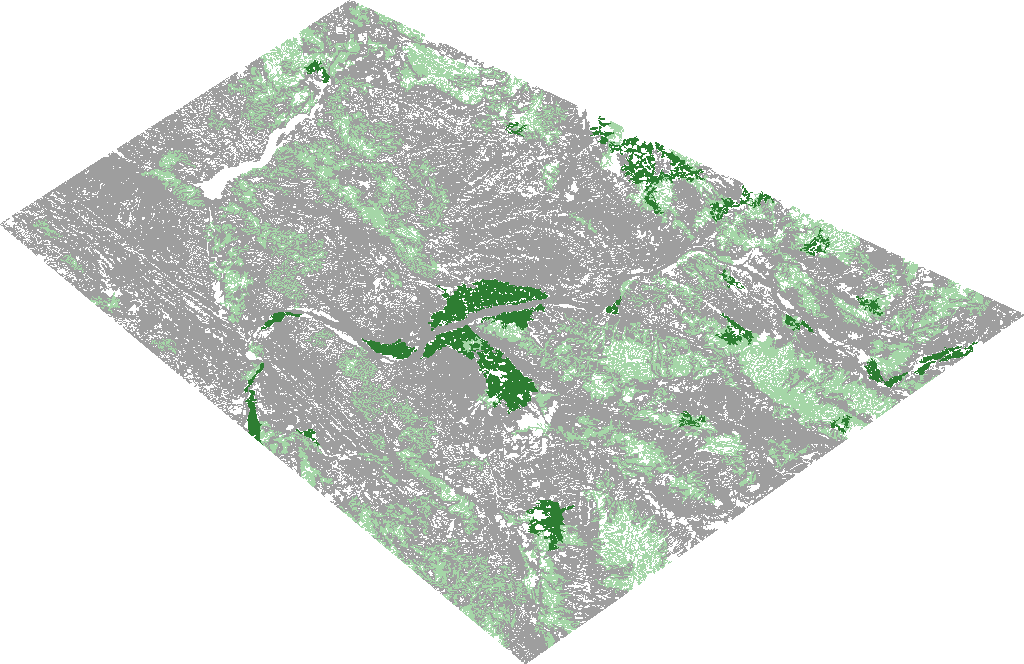

[GMM] thumbnail dimensions(long side) used: 1024
[GMM] Semantic (0/1/2) PNG → /content/sem3_exports/png/sem3_gmm_20250220_20250419.png


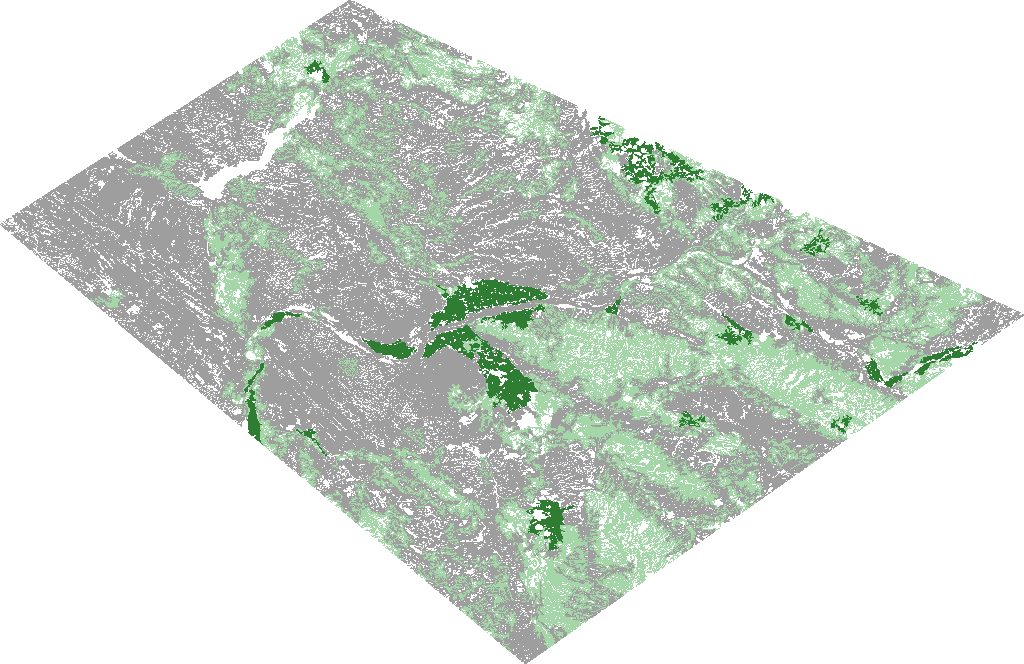


KMeans — class membership
  pixels: {0: 7010128, 1: 2755522, 2: 670101} | total: 10435751
  area_ha: {0: 59661.654, 1: 23451.846, 2: 5703.009} | total_ha: 88816.509



GMM — class membership
  pixels: {0: 6258658, 1: 3551970, 2: 653132} | total: 10463760
  area_ha: {0: 53264.46, 1: 30231.679, 2: 5558.651} | total_ha: 89054.79

[Cell 13] Done. PNGs → /content/sem3_exports/png/sem3_kmeans_20250220_20250419.png, /content/sem3_exports/png/sem3_gmm_20250220_20250419.png


In [20]:
from __future__ import annotations
import os, json, io
from typing import Dict, List, Optional, Any
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display as _display, Image as _IPyImage

import ee, geemap
import requests

# -------- 13.0: Preconditions --------
assert "AOI" in globals(), "[Cell 13] Missing AOI. Please run Cells 3–12 first."
assert "FEAT_IMG" in globals(), "[Cell 13] Missing FEAT_IMG (feature stack). Run Cells 4–5."

BASE_EXPORT_DIR = globals().get("EXPORT_DIR_LOCAL", "/content/sem3_exports")
OUT_DIR = os.path.join(BASE_EXPORT_DIR, "stats")
PNG_DIR = os.path.join(BASE_EXPORT_DIR, "png")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PNG_DIR, exist_ok=True)

_date_from = str(globals().get("DATE_FROM", "NA"))
_date_to   = str(globals().get("DATE_TO", "NA"))
DATE_TAG = f"{_date_from.replace('-','')}_{_date_to.replace('-','')}"

# -------- 13.1: Config knobs --------
CLASSES: List[int] = list(globals().get("CLASSES", [0, 1, 2]))
AREA_SCALE: int = int(globals().get("AREA_SCALE", 10))
MAX_PIXELS: float = float(globals().get("MAX_PIXELS", 1e13))
SAMPLE_SCALE_SEM: int = int(globals().get("SAMPLE_SCALE_SEM", 20))
CLIENT_PULL_MAX: int = int(globals().get("CLIENT_PULL_MAX", 5000))
SEED: int = int(globals().get("SEED", 42))
PALETTE = ["#9e9e9e", "#a5d6a7", "#2e7d32"]   # 0,1,2

WATER_NDWI: float  = float(globals().get("WATER_NDWI", 0.18))
WATER_NDVI: float  = float(globals().get("WATER_NDVI", 0.20))
NONVEG_NDVI: float = float(globals().get("NONVEG_NDVI", 0.18))

# Prefer a tiny rectangular ring for thumbnails (low payload)
def _bounds_ring(g: ee.Geometry) -> List[List[float]]:
    rect = ee.Geometry(g).bounds().coordinates().get(0)
    return ee.List(rect).getInfo()

if "REGION_FOR_THUMBS" in globals():
    THUMB_REGION = globals()["REGION_FOR_THUMBS"]
else:
    THUMB_REGION = _bounds_ring(AOI)

# -------- Helpers --------
def _hectares(m2: float) -> float:
    return float(m2) / 10_000.0

def _area_by_class(sem_img: ee.Image, geom: ee.Geometry, classes: List[int], scale: int) -> Dict[int, float]:
    pa = ee.Image.pixelArea()
    out: Dict[int, float] = {}
    for c in classes:
        a = (pa.updateMask(sem_img.eq(int(c)))
               .reduceRegion(ee.Reducer.sum(), geometry=geom, scale=scale,
                             maxPixels=MAX_PIXELS, bestEffort=True)
               .get("area"))
        try:
            out[c] = float(ee.Number(a).getInfo() or 0.0)
        except Exception:
            out[c] = 0.0
    return out

def _counts_from_raster(sem_img: ee.Image, geom: ee.Geometry, scale: int) -> Dict[int, int]:
    try:
        hist = sem_img.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=geom, scale=scale,
            maxPixels=MAX_PIXELS, bestEffort=True
        ).get("sem3")
        h = ee.Dictionary(hist).getInfo() if hist is not None else {}
        return {int(k): int(v) for k, v in (h or {}).items()}
    except Exception:
        return {}

def _ensure_lai_col(df: pd.DataFrame) -> pd.DataFrame:
    if "LAI" not in df.columns and "NDVI" in df.columns:
        df = df.copy()
        df["LAI"] = (df["NDVI"].clip(lower=0) * 3.618) - 0.118
    return df

def _sample_fc_to_pandas(fc: ee.FeatureCollection, columns: List[str], limit: int = 5000, chunk: int = 1000) -> pd.DataFrame:
    limit = int(min(limit, 5000))
    size = int(ee.Number(fc.size()).min(limit).getInfo() or 0)
    if size == 0:
        return pd.DataFrame(columns=columns)
    rows = []
    for start in range(0, size, chunk):
        this_n = min(chunk, size - start)
        sub = ee.FeatureCollection(fc.toList(this_n, start))
        info = sub.getInfo()
        feats = info.get("features", []) or []
        for f in feats:
            props = f.get("properties", {}) or {}
            rows.append({k: props.get(k, None) for k in columns})
    return pd.DataFrame(rows)

def _derive_sem_mapping_from_sample(df_sem: pd.DataFrame, raw_col: str) -> Dict[int, int]:
    assert "derive_semantic_mapping" in globals(), "[Cell 13] Run Cell 9 first to define derive_semantic_mapping()."
    df_sem = _ensure_lai_col(df_sem)
    mapping, _details = derive_semantic_mapping(
        df_sem, raw_col,
        prefer_feats=["NDVI", "MSAVI2", "NDRE", "LAI", "NDWI"],
        water_ndwi=WATER_NDWI,
        water_ndvi=WATER_NDVI,
        nonveg_ndvi=NONVEG_NDVI,
        weights=globals().get("DEFAULT_WEIGHTS", None)
    )
    return {int(k): int(v) for k, v in mapping.items()}

def _smooth_semantic(img: ee.Image) -> ee.Image:
    SMOOTH_RADIUS_M = int(globals().get("SMOOTH_RADIUS_M", 30))
    MIN_PATCH_PX = int(globals().get("MIN_PATCH_PX", 100))
    out = img
    if SMOOTH_RADIUS_M > 0:
        out = out.focal_mode(radius=SMOOTH_RADIUS_M, units="meters")
    if MIN_PATCH_PX > 0:
        big = out.connectedPixelCount(maxSize=MIN_PATCH_PX, eightConnected=True).gte(MIN_PATCH_PX)
        out = out.updateMask(big)
    return out

def _thumb_png(img: ee.Image, out_path: str, palette: List[str] = PALETTE,
               region_ring: Optional[List[List[float]]] = None,
               long_side_candidates: List[int] = [4096, 3072, 2048, 1536, 1024, 768]):
    """
    Build a small visualize() image and request a thumbnail with a bounded 'dimensions'
    instead of 'scale'. On 400-error (48MB limit), retry with smaller dimensions.
    """
    region = region_ring or THUMB_REGION
    vis = img.visualize(min=0, max=2, palette=palette, opacity=1.0)
    last_err = None
    for L in long_side_candidates:
        params = {
            "region": [region],      # ring (rectangular) → tiny payload
            "dimensions": L,         # bound the long side; server keeps aspect
            "format": "png"
        }
        try:
            url = vis.getThumbURL(params)
            r = requests.get(url, timeout=180)
            r.raise_for_status()
            Image.open(io.BytesIO(r.content)).save(out_path, optimize=True)
            return out_path, L
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Thumbnail failed after retries (last error: {last_err})")

def _display_png(path: str, title: str):
    print(title, "→", path)
    _display(_IPyImage(filename=path))

# -------- 13.2: Locate or build KMeans semantic raster --------
sem_kmeans: Optional[ee.Image] = None

if "sem_smooth" in globals():
    sem_kmeans = ee.Image(globals()["sem_smooth"]).rename("sem3")
elif "sem_img_kmeans" in globals():
    sem_kmeans = _smooth_semantic(ee.Image(globals()["sem_img_kmeans"]).rename("sem3"))
else:
    try:
        feat_sel = FEAT_IMG
        K_EE = int(globals().get("K_EE", 10))
        train = feat_sel.sample(region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=int(globals().get("SAMPLE_ROWS_SEM", 20000)),
                                seed=SEED, geometries=False)
        clusterer = ee.Clusterer.wekaKMeans(K_EE, seed=SEED).train(train)
        k_raw = feat_sel.cluster(clusterer).rename("k_raw")
        cols = [c for c in ["NDVI","MSAVI2","NDRE","NDWI","LAI","k_raw"] if c in feat_sel.bandNames().getInfo()] + ["k_raw"]
        df_sem_km = _sample_fc_to_pandas(feat_sel.addBands(k_raw).sample(
            region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=CLIENT_PULL_MAX,
            seed=SEED, geometries=False).limit(CLIENT_PULL_MAX),
            columns=list(dict.fromkeys(cols)), limit=CLIENT_PULL_MAX, chunk=1000)
        mapping_km = _derive_sem_mapping_from_sample(df_sem_km, "k_raw")
        src_ids = sorted(mapping_km.keys())
        dst_ids = [mapping_km[i] for i in src_ids]
        sem_kmeans = k_raw.remap(src_ids, dst_ids, 0).rename("sem3")
        sem_kmeans = _smooth_semantic(sem_kmeans.updateMask(feat_sel.select(0).mask()).clip(AOI))
        print("[Cell 13] KMeans semantic was rebuilt on-the-fly.")
    except Exception as e:
        print("[Cell 13] KMeans semantic not available and rebuild failed:", e)

# -------- 13.3: Locate or build GMM semantic raster --------
sem_gmm: Optional[ee.Image] = None

if "sem_gmm_smooth" in globals():
    sem_gmm = ee.Image(globals()["sem_gmm_smooth"]).rename("sem3")
elif "k_raw_gmm" in globals():
    try:
        k_raw_gmm = ee.Image(globals()["k_raw_gmm"]).rename("k_raw")
        feat_sel = FEAT_IMG
        cols = [c for c in ["NDVI","MSAVI2","NDRE","NDWI","LAI","k_raw"] if c in feat_sel.bandNames().getInfo()] + ["k_raw"]
        df_sem_gmm = _sample_fc_to_pandas(feat_sel.addBands(k_raw_gmm).sample(
            region=AOI, scale=SAMPLE_SCALE_SEM, numPixels=CLIENT_PULL_MAX,
            seed=SEED, geometries=False).limit(CLIENT_PULL_MAX),
            columns=list(dict.fromkeys(cols)), limit=CLIENT_PULL_MAX, chunk=1000)
        mapping_gmm = _derive_sem_mapping_from_sample(df_sem_gmm, "k_raw")
        src_ids = sorted(mapping_gmm.keys())
        dst_ids = [mapping_gmm[i] for i in src_ids]
        sem_gmm = k_raw_gmm.remap(src_ids, dst_ids, 0).rename("sem3")
        sem_gmm = _smooth_semantic(sem_gmm.updateMask(feat_sel.select(0).mask()).clip(AOI))
        print("[Cell 13] GMM semantic built from k_raw_gmm + mapping.")
    except Exception as e:
        print("[Cell 13] GMM semantic rebuild from k_raw_gmm failed:", e)
elif "sem_best_smooth" in globals() and globals().get("BEST_SEM3_COL", None) and "gmm" in str(globals().get("BEST_SEM3_COL", "")).lower():
    sem_gmm = ee.Image(globals()["sem_best_smooth"]).rename("sem3")

# -------- 13.4: Make PNGs (dimension-capped) & display --------
pngs_made = []

if sem_kmeans is not None:
    km_png = os.path.join(PNG_DIR, f"sem3_kmeans_{DATE_TAG}.png")
    path, used_dim = _thumb_png(sem_kmeans, km_png, palette=PALETTE, region_ring=THUMB_REGION)
    print(f"[KMeans] thumbnail dimensions(long side) used: {used_dim}")
    _display_png(path, "[KMeans] Semantic (0/1/2) PNG")
    pngs_made.append(path)
else:
    print("[Cell 13] KMeans semantic PNG skipped (image unavailable).")

if sem_gmm is not None:
    gm_png = os.path.join(PNG_DIR, f"sem3_gmm_{DATE_TAG}.png")
    path, used_dim = _thumb_png(sem_gmm, gm_png, palette=PALETTE, region_ring=THUMB_REGION)
    print(f"[GMM] thumbnail dimensions(long side) used: {used_dim}")
    _display_png(path, "[GMM] Semantic (0/1/2) PNG")
    pngs_made.append(path)
else:
    print("[Cell 13] GMM semantic PNG skipped (image unavailable). "
          "Run Cell 12-B (GMM) to generate k_raw_gmm/sem_gmm_smooth, then re-run this cell.")

# -------- 13.5: Counts per class (pixels & hectares) for both models --------
def _print_counts(title: str, sem_img: ee.Image):
    px_counts = _counts_from_raster(sem_img, AOI, AREA_SCALE)
    area_m2 = _area_by_class(sem_img, AOI, CLASSES, AREA_SCALE)
    total_px = int(sum(px_counts.get(c, 0) for c in CLASSES))
    total_m2 = float(sum(area_m2.get(c, 0.0) for c in CLASSES))
    print(f"\n{title}")
    print("  pixels:", {c: int(px_counts.get(c, 0)) for c in CLASSES}, "| total:", total_px)
    print("  area_ha:", {c: round(_hectares(area_m2.get(c, 0.0)), 3) for c in CLASSES},
          "| total_ha:", round(_hectares(total_m2), 3))

if sem_kmeans is not None:
    _print_counts("KMeans — class membership", sem_kmeans)

if sem_gmm is not None:
    _print_counts("GMM — class membership", sem_gmm)

# -------- 13.6: Optional AOI-level CSV/JSON summary --------
rows = []
def _save_summary(tag: str, sem_img: ee.Image):
    area_m2 = _area_by_class(sem_img, AOI, CLASSES, AREA_SCALE)
    total_m2 = float(sum(area_m2.values()))
    row = {"model": tag, "date_from": _date_from, "date_to": _date_to, "scale_m": AREA_SCALE,
           "total_ha": _hectares(total_m2)}
    for c in CLASSES: row[f"c{c}_ha"] = _hectares(area_m2[c])
    return row

if sem_kmeans is not None: rows.append(_save_summary("kmeans", sem_kmeans))
if sem_gmm   is not None: rows.append(_save_summary("gmm", sem_gmm))

if rows:
    _df = pd.DataFrame(rows)
    _df.to_csv(os.path.join(OUT_DIR, f"sem3_models_aoi_{DATE_TAG}.csv"), index=False)
    with open(os.path.join(OUT_DIR, f"sem3_models_aoi_{DATE_TAG}.json"), "w", encoding="utf-8") as f:
        json.dump(_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print("\n[Cell 13] Done.", ("PNGs → " + ", ".join(pngs_made)) if pngs_made else "No PNGs generated.")
